In [3]:
import matplotlib as mpl
import seaborn as sns
import os
import torch
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from itertools import combinations
! pwd
from parameters_modelAB import modelA_priors, modelB_priors, pop_size_A, gene_probs, syn_probs_by_gene, passages
from simulator_model_AB import simulate as simulate_AB

/sternadi/home/volume3/yael/pycharm/MS2_PG/data_analysis


ModuleNotFoundError: No module named 'parameters_modelAB'

In [ ]:
mpl.rcParams['xtick.labelsize'] = 15 
mpl.rcParams['ytick.labelsize'] = 15 
plt.rcParams['figure.dpi'] = 300

In [ ]:
model_A_posterior_samples_path ='/sternadi/home/volume3/yael/model_AB/model_A/A1/results_final/MOI0.1_line_mean_20k_samples_mean_posterior_samples.csv'
model_A_stats_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_final/MOI0.1_line_mean_20k_samples_mean_stats.csv'

model_A_ens_posterior_samples_path ='/sternadi/home/volume3/yael/model_AB/model_A/A1/results_final/MOI0.1_line_mean_20k_samples_mean_ensemble_posterior_samples.csv'
model_A_ens_stats_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_final/MOI0.1_line_mean_20k_samples_mean_ensemble_stats.csv'

model_B_posterior1_samples_path ='/sternadi/home/volume3/yael/model_AB/model_B/results_1/MOI10_line_E_G_H_20k_samples_mean_EGH_posterior_samples.csv'
model_B_stats1_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_1/MOI10_line_E_G_H_20k_samples_mean_EGH_stats.csv'

model_B_posterior2_samples_path ='/sternadi/home/volume3/yael/model_AB/model_B/results_2/MOI10_line_E_G_H_20k_samples_mean_EGH_posterior_samples.csv'
model_B_stats2_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_2/MOI10_line_E_G_H_20k_samples_mean_EGH_stats.csv'

model_B_posterior1_lineA_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_A/MOI10_line_A_20k_samples_line_A_posterior_samples.csv'
model_B_stats1_lineA_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_A/MOI10_line_A_20k_samples_line_A_stats.csv'
model_B_posterior1_lineE_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_E/MOI10_line_E_20k_samples_line_E_posterior_samples.csv'
model_B_stats1_lineE_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_E/MOI10_line_E_20k_samples_line_E_stats.csv'
model_B_posterior1_lineG_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_G/MOI10_line_G_20k_samples_line_G_posterior_samples.csv'
model_B_stats1_lineG_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_G/MOI10_line_G_20k_samples_line_G_stats.csv'
model_B_posterior1_lineH_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_H/MOI10_line_H_20k_samples_line_H_posterior_samples.csv'
model_B_stats1_lineH_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_by_line/line_H/MOI10_line_H_20k_samples_line_H_stats.csv'

model_B_control_line1_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line1/MOI0.1_line_1_20k_samples_line1_posterior_samples.csv'
model_B_control_line1_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line1/MOI0.1_line_1_20k_samples_line1_stats.csv'
model_B_control_line2_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line2/MOI0.1_line_2_20k_samples_line2_posterior_samples.csv'
model_B_control_line2_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line2/MOI0.1_line_2_20k_samples_line2_stats.csv'
model_B_control_line3_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line3/MOI0.1_line_3_20k_samples_line3_posterior_samples.csv'
model_B_control_line3_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B2/results_line3/MOI0.1_line_3_20k_samples_line3_stats.csv'

In [ ]:
param_2_name = {
'mu': r'Mutation Rate ($\mu$)',
'w_syn': r'Syn effect ($\omega_{syn}$)',
'w_nonsyn_mat': r'maturation non-syn effect ($\omega_{ns{,}mat}$)',
'w_nonsyn_cp': r'coat protein non-syn effect ($\omega_{ns{,}cp}$)',
'w_nonsyn_lys': r'lysis non-syn effect ($\omega_{ns{,}lys}$)',
'w_nonsyn_rep': r'replicase non-syn effect ($\omega_{ns{,}rep}$)',
'w_ada': r'Adaptive effect ($\omega_{ada}$)',
'p_ada_syn': r'Adaptive syn prob ($P_{ada{,}syn}$)',
"p_ada_ns_mat": r'Adaptive maturation non-syn prob ($P_{ada{,}ns{,}mat}$)',
"p_ada_ns_cp": r'Adaptive coat protein non-syn prob ($P_{ada{,}ns{,}cp}$)',
"p_ada_ns_lys": r'Adaptive lysis non-syn prob ($P_{ada{,}ns{,}lys}$)',
"p_ada_ns_rep": r'Adaptive replicase non-syn prob ($P_{ada{,}ns{,}rep}$)',
"p_mat_nonsyn_rec": r'maturation recessive prob ($P_{mat{,}ns{,}rec}$)',
"p_cp_nonsyn_rec": r'coat protein recessive prob ($P_{cp{,}ns{,}rec}$)',
"p_lys_nonsyn_rec": r'lysis recessive prob ($P_{lys{,}ns{,}rec}$)',
"p_rep_nonsyn_rec": r'replicase recessive prob ($P_{rep{,}ns{,}rec}$)',
}

In [ ]:
param_2_name2 = {
    'mu': r'Mutation Rate' + '\n' + r'($\mu$)',
    'w_syn': r'Syn effect' + '\n' + r'($\omega_{syn}$)',
    'w_nonsyn_mat': r'Maturation non-syn effect' + '\n' + r'($\omega_{ns{,}mat}$)',
    'w_nonsyn_cp': r'Coat non-syn effect' + '\n' + r'($\omega_{ns{,}cp}$)',
    'w_nonsyn_lys': r'Lysis non-syn effect' + '\n' + r'($\omega_{ns{,}lys}$)',
    'w_nonsyn_rep': r'Replicase non-syn effect' + '\n' + r'($\omega_{ns{,}rep}$)',
    'w_ada': r'Adaptive effect' + '\n' + r'($\omega_{ada}$)',
    'p_ada_syn': r'Adaptive syn prob' + '\n' + r'($P_{ada{,}syn}$)',
    "p_ada_ns_mat": r'Adaptive maturation non-syn prob' + '\n' + r'($P_{ada{,}ns{,}mat}$)',
    "p_ada_ns_cp": r'Adaptive coat non-syn prob' + '\n' + r'($P_{ada{,}ns{,}cp}$)',
    "p_ada_ns_lys": r'Adaptive lysis non-syn prob' + '\n' + r'($P_{ada{,}ns{,}lys}$)',
    "p_ada_ns_rep": r'Adaptive replicase non-syn prob' + '\n' + r'($P_{ada{,}ns{,}rep}$)',
    "p_mat_nonsyn_rec": r'Maturation recessive prob' + '\n' + r'($P_{mat{,}ns{,}rec}$)',
    "p_cp_nonsyn_rec": r'Coat recessive prob' + '\n' + r'($P_{cp{,}ns{,}rec}$)',
    "p_lys_nonsyn_rec": r'Lysis recessive prob' + '\n' + r'($P_{lys{,}ns{,}rec}$)',
    "p_rep_nonsyn_rec": r'Replicase recessive prob' + '\n' + r'($P_{rep{,}ns{,}rec}$)',
}

In [ ]:
def plot_posteriors_overlay(
    post_dfs,
    stats_list,
    save_plot,
    plot_output_dir,
    plot_name,
    param_2_name,
    priors_dict=None,
    params_to_use=None, # lst of parameters to use
    bins=50,
    labels=None,
    colors=None,
    alpha=0.35,
    ncols=3,
    figsize_per_row=4.0,
):
    """
    Overlay up to 3 posterior histograms per parameter (same axes), add MAP + 95% HDI per posterior,
    and optionally overlay a Uniform prior. Uses a single shared legend for the whole figure.

    Parameters
    ----------
    post_dfs : list[pd.DataFrame]
        List of posterior samples dataframes. Length must be 1..3. Each df columns are parameters.
    stats_list : list[pd.DataFrame]
        List of stats tables corresponding to post_dfs. Length must match post_dfs.
        Each stats df must contain columns: ['param', 'MAP', 'HDI_low', 'HDI_high'].
    param_2_name : dict
        Mapping from parameter column name -> display name.
    priors_dict : dict, optional
        { 'param_name': (low, high) } for uniform priors.

    Notes
    -----
    - All posteriors must share the same set of columns (order can differ).
    - The legend is figure-level (shared across subplots).
    """

    if not isinstance(post_dfs, (list, tuple)) or len(post_dfs) == 0:
        raise ValueError("post_dfs must be a non-empty list/tuple of DataFrames (length 1..3).")
    if len(post_dfs) > 4:
        raise ValueError(f"Supports up to 3 posteriors, got {len(post_dfs)}.")
    if not isinstance(stats_list, (list, tuple)) or len(stats_list) != len(post_dfs):
        raise ValueError("stats_list must be a list/tuple with the same length as post_dfs.")

    k = len(post_dfs)
    # Defaults
    if labels is None:
        labels = [f"Posterior {i+1}" for i in range(k)]
    if len(labels) != k:
        raise ValueError("labels length must match number of posteriors.")

    if colors is None:
        # Reasonable defaults for up to 3
        colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"][:k]
    if len(colors) != k:
        raise ValueError("colors length must match number of posteriors.")

    # Ensure same parameter set across dfs
    cols0 = list(post_dfs[0].columns)
    set0 = set(cols0)
    for idx, df in enumerate(post_dfs[1:], start=2):
        if set(df.columns) != set0:
            missing = set0 - set(df.columns)
            extra = set(df.columns) - set0
            raise ValueError(
                f"All post_dfs must have the same columns.\n"
                f"Mismatch at post_dfs[{idx-1}]. Missing: {sorted(missing)}; Extra: {sorted(extra)}"
            )

    cols = cols0
    if params_to_use==None:
        params_to_plot = list(priors_dict.keys())
    else:
        params_to_plot = params_to_use
        
    n_params = len(params_to_plot)

    nrows = int(np.ceil(n_params / ncols))
    figsize = (18, figsize_per_row * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.set_dpi(300)
    axes_flat = np.array(axes).flatten()

    legend_handles = {}
    prior_present = False

    for i, col in enumerate(params_to_plot):
        ax = axes_flat[i]

        all_vals = []
        for df in post_dfs:
            v = df[col].values
            v = v[np.isfinite(v)]
            if v.size:
                all_vals.append(v)

        if not all_vals:
            # No finite values in any posterior for this param
            ax.set_title(f"{param_2_name.get(col, col)}", fontweight="medium", fontsize=20, pad=15)
            ax.text(0.5, 0.5, "No finite samples", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        x_min = min(np.min(v) for v in all_vals)
        x_max = max(np.max(v) for v in all_vals)

        if priors_dict and col in priors_dict:
            prior_low, prior_high = priors_dict[col]
            x_min = min(x_min, prior_low)
            x_max = max(x_max, prior_high)

        pad = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        ax.set_xlim(x_min - pad, x_max + pad)

        # Plot each posterior + MAP/HDI
        for j in range(k):
            vals = post_dfs[j][col].values
            vals = vals[np.isfinite(vals)]
            post_label = f'Posterior ({labels[j]})'
            h = ax.hist(
                vals,
                bins=bins,
                density=True,
                alpha=alpha,
                color=colors[j],
                label=post_label,  # for legend collection
            )
            # hist returns (n, bins, patches)
            if post_label not in legend_handles: # labels[j]
                legend_handles[post_label] = h[2][0]  # labels[j]

            # MAP/HDI
            st = stats_list[j]
            row = st.loc[st["param"] == col]
            if not row.empty:
                map_val = row["MAP"].values[0]
                hdi_low = row["HDI_low"].values[0]
                hdi_high = row["HDI_high"].values[0]

                # MAP line
#                 map_label = f"MAP ({labels[j]})"
#                 line = ax.axvline(map_val, color=colors[j], linestyle="--", linewidth=2, label=map_label)
#                 if map_label not in legend_handles:
#                     legend_handles[map_label] = line

                # HDI span
                hdi_label = f"95% HDI ({labels[j]})"
                span = ax.axvspan(hdi_low, hdi_high, color=colors[j], alpha=0.12, label=hdi_label)
                if hdi_label not in legend_handles:
                    legend_handles[hdi_label] = span

        # Prior overlay
        if priors_dict and col in priors_dict:
            prior_low, prior_high = priors_dict[col]
            if prior_high <= prior_low:
                raise ValueError(f"Invalid prior range for {col}: ({prior_low}, {prior_high})")
            prior_height = 1.0 / (prior_high - prior_low)
            prior_line = ax.hlines(
                y=prior_height,
                xmin=prior_low,
                xmax=prior_high,
                color="goldenrod",  # darkorange
                linewidth=2,
                label="Prior",
            )
            prior_present = True
            if "Prior" not in legend_handles:
                # hlines returns a LineCollection
                legend_handles["Prior"] = prior_line

        ax.set_title(f"{param_2_name.get(col, col)}", fontweight="medium", fontsize=20, pad=15)
        if i % ncols == 0:
            ax.set_ylabel("Density", fontsize=18, labelpad=15)

    # Hide unused axes
    for j in range(n_params, len(axes_flat)):
        axes_flat[j].axis("off")

    # Shared legend for the whole figure
    # Order: posteriors, then MAP/HDI per posterior, then Prior.
    ordered_keys = []
    ordered_keys += labels
    for lab in labels:
        ordered_keys.append(f"Posterior ({lab})")
        ordered_keys.append(f"MAP ({lab})")
        ordered_keys.append(f"95% HDI ({lab})")
    if prior_present:
        ordered_keys.append("Prior")

    handles = [legend_handles[k] for k in ordered_keys if k in legend_handles]
    leg_labels = [k for k in ordered_keys if k in legend_handles]

    # Put legend above the plots
    fig.legend(
        handles,
        leg_labels,
        loc="upper center",
        ncol=min(len(leg_labels), 3),
        frameon=True,
        fontsize=16,
        bbox_to_anchor=(0.5, 1.06),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave space for legend (0.99 for single posterior)

    if save_plot:
        os.makedirs(plot_output_dir, exist_ok=True)
        save_path = os.path.join(plot_output_dir, f"{plot_name}.png")
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved posterior plot to {save_path}")
        plt.close(fig)
    else:
        plt.show()

In [ ]:
def plot_posteriors_overlay_wraper(posterior_samples_path_lst, stats_path_lst,model,param_2_name,labels,params_to_use=None, plot_output_dir=None,ncols=3,colors=None):
    stats_df_lst = []
    posterior_samples_df_lst = []
    for i in range(len(posterior_samples_path_lst)):
        posterior_samples_df_lst.append(pd.read_csv(posterior_samples_path_lst[i]))
        stats_df_lst.append(pd.read_csv(stats_path_lst[i]))
    priors_dict = modelA_priors if model == 'A' else modelB_priors
    save_fig = False if plot_output_dir is None else True
    plot_posteriors_overlay(posterior_samples_df_lst,stats_df_lst,save_fig,plot_output_dir,'',param_2_name,priors_dict,labels=labels,params_to_use=params_to_use,ncols=ncols,colors=colors)
    


In [ ]:
# model A - N=2*10**7 
plot_posteriors_overlay_wraper(
    [model_A_posterior_samples_path],
    [model_A_stats_path],
    'A',
    param_2_name,
    labels=['ModelA'],
    # colors=['rebeccapurple']
)

In [ ]:
# model B - N=2*10**7 (N similar to N in model A)
plot_posteriors_overlay_wraper(
    [model_B_posterior1_samples_path],
    [model_B_stats1_path],
    'B',
    param_2_name,
    labels=['ModelB'],
    colors=['rebeccapurple']
)

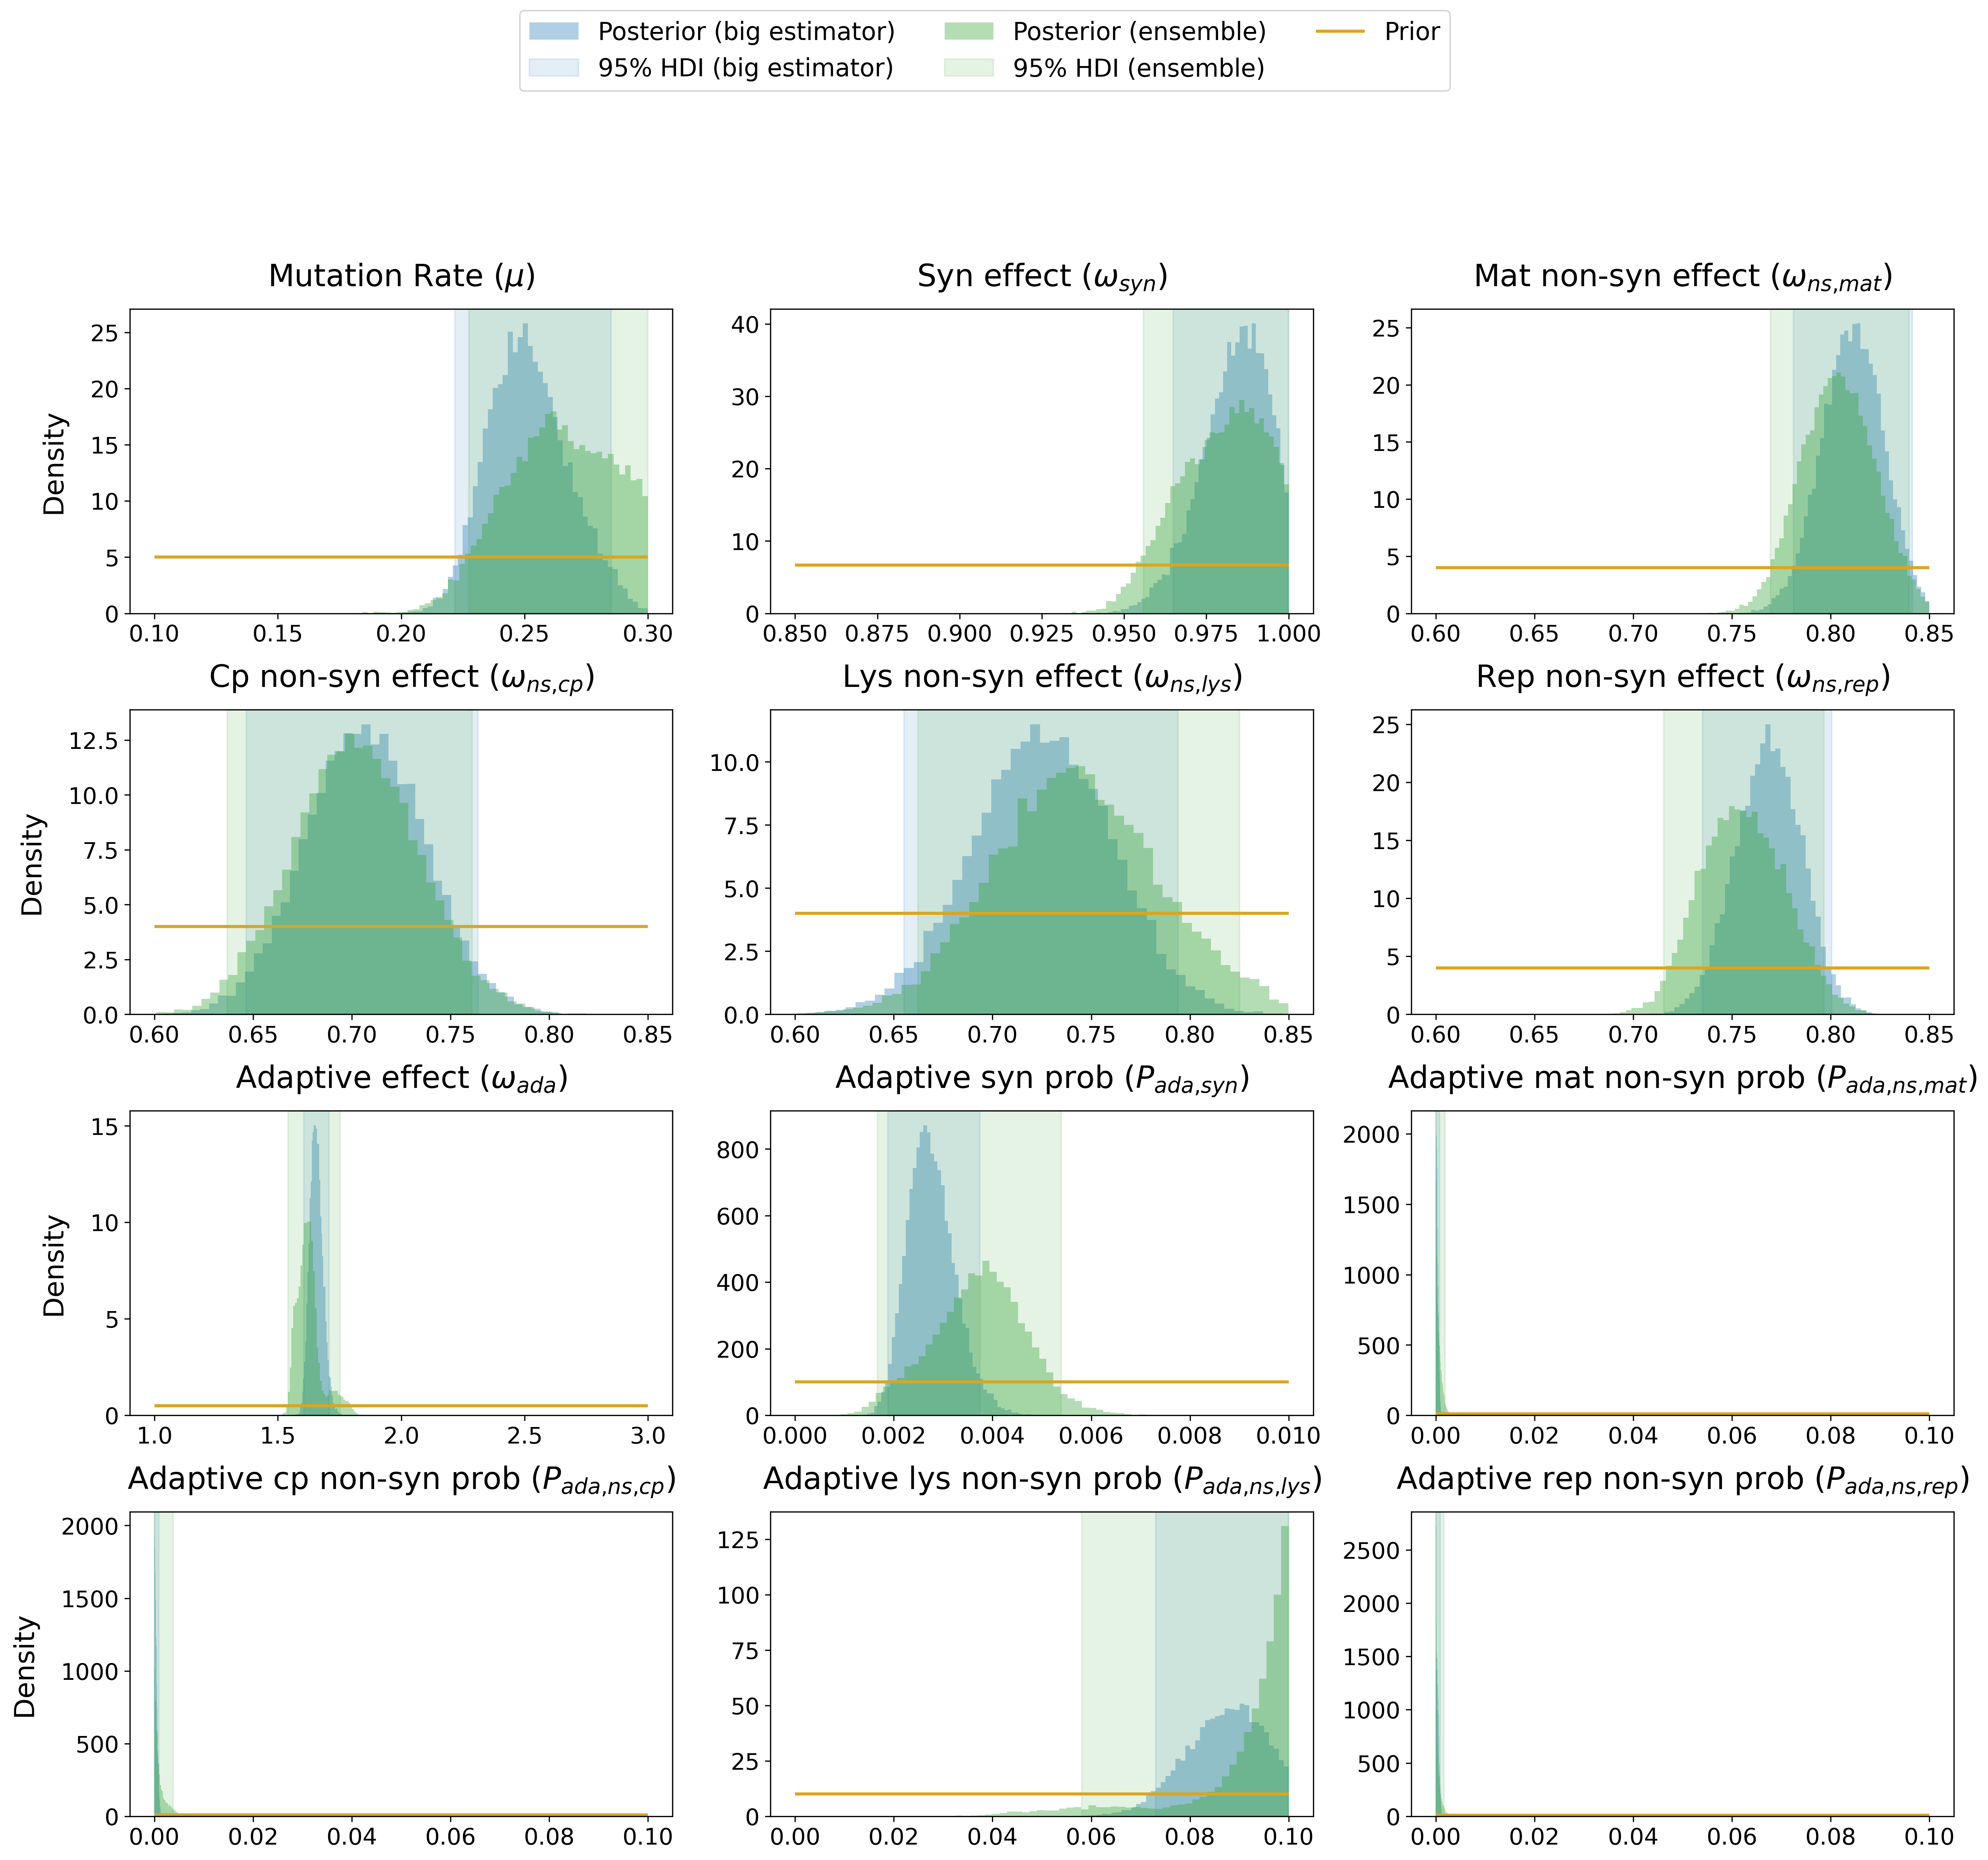

In [10]:
# model A - big estimator VS ensemble
plot_posteriors_overlay_wraper(
    [model_A_posterior_samples_path,model_A_ens_posterior_samples_path],
    [model_A_stats_path,model_A_ens_stats_path],
    'A',
    param_2_name,
    labels=("big estimator", "ensemble"),
)

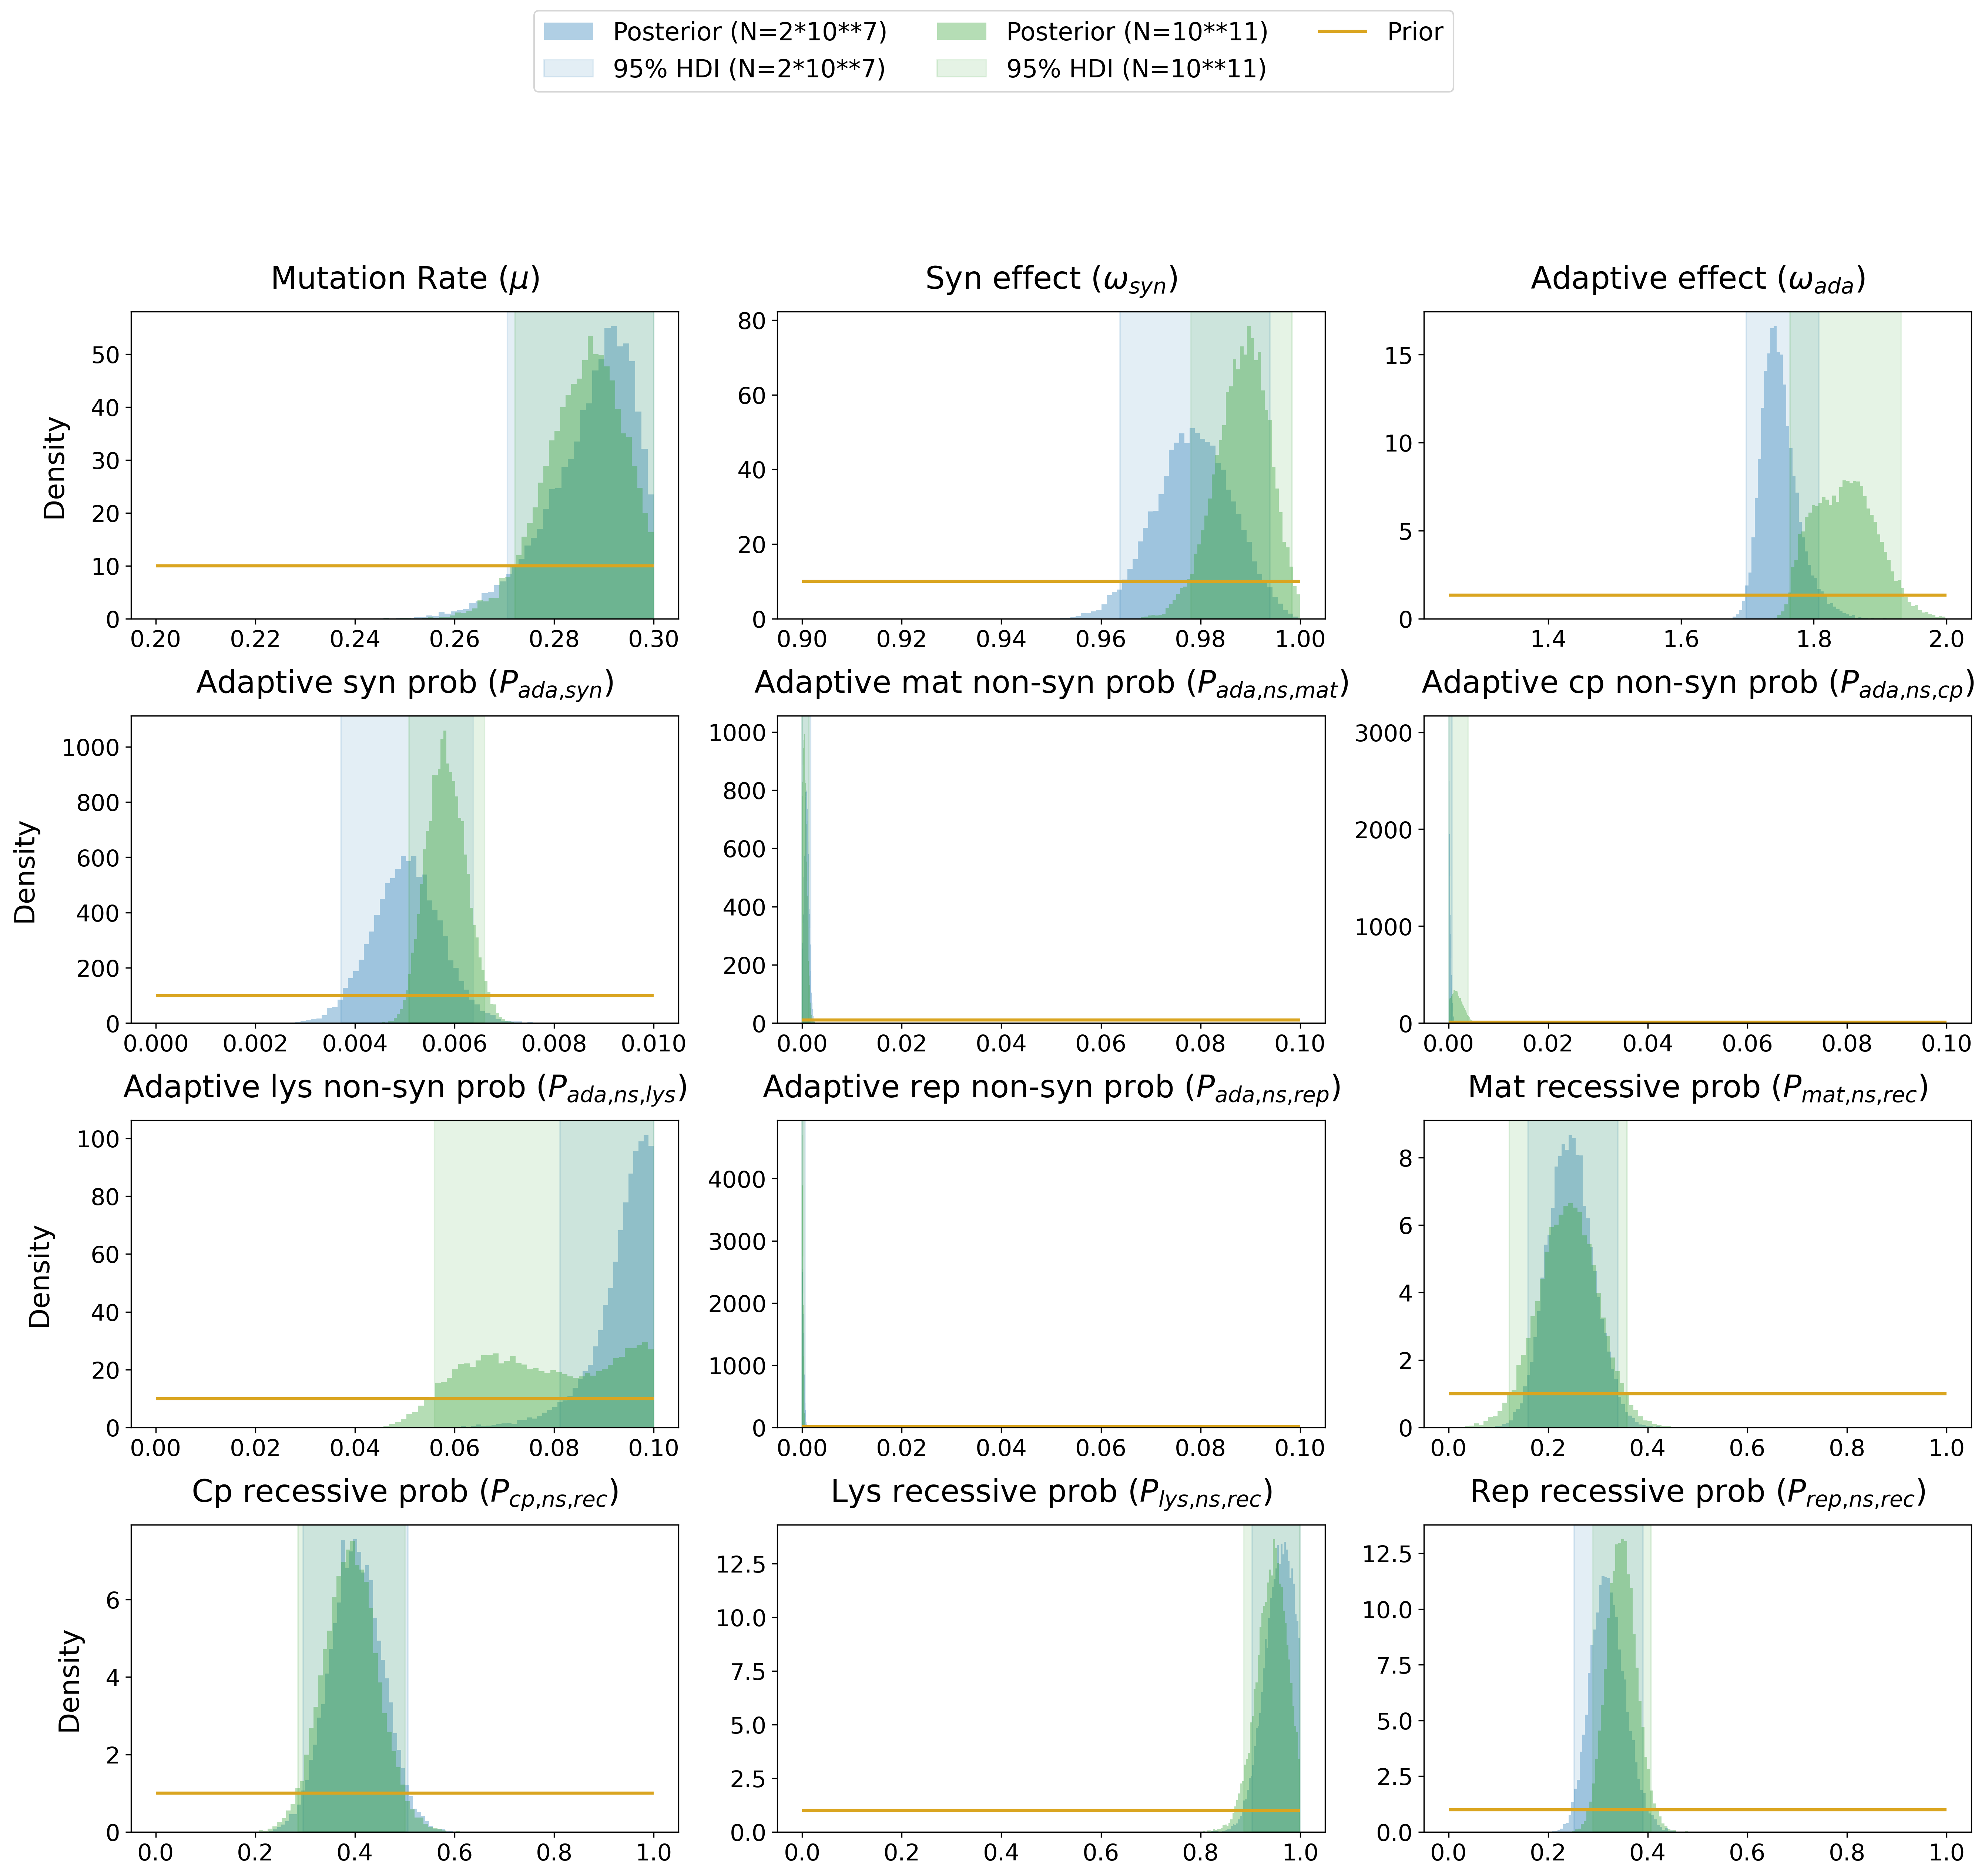

In [11]:
plot_posteriors_overlay_wraper(
    [model_B_posterior1_samples_path,model_B_posterior2_samples_path],
    [model_B_stats1_path,model_B_stats2_path],
    'B',
    param_2_name,
    labels=("N=2*10**7", "N=10**11"),
)

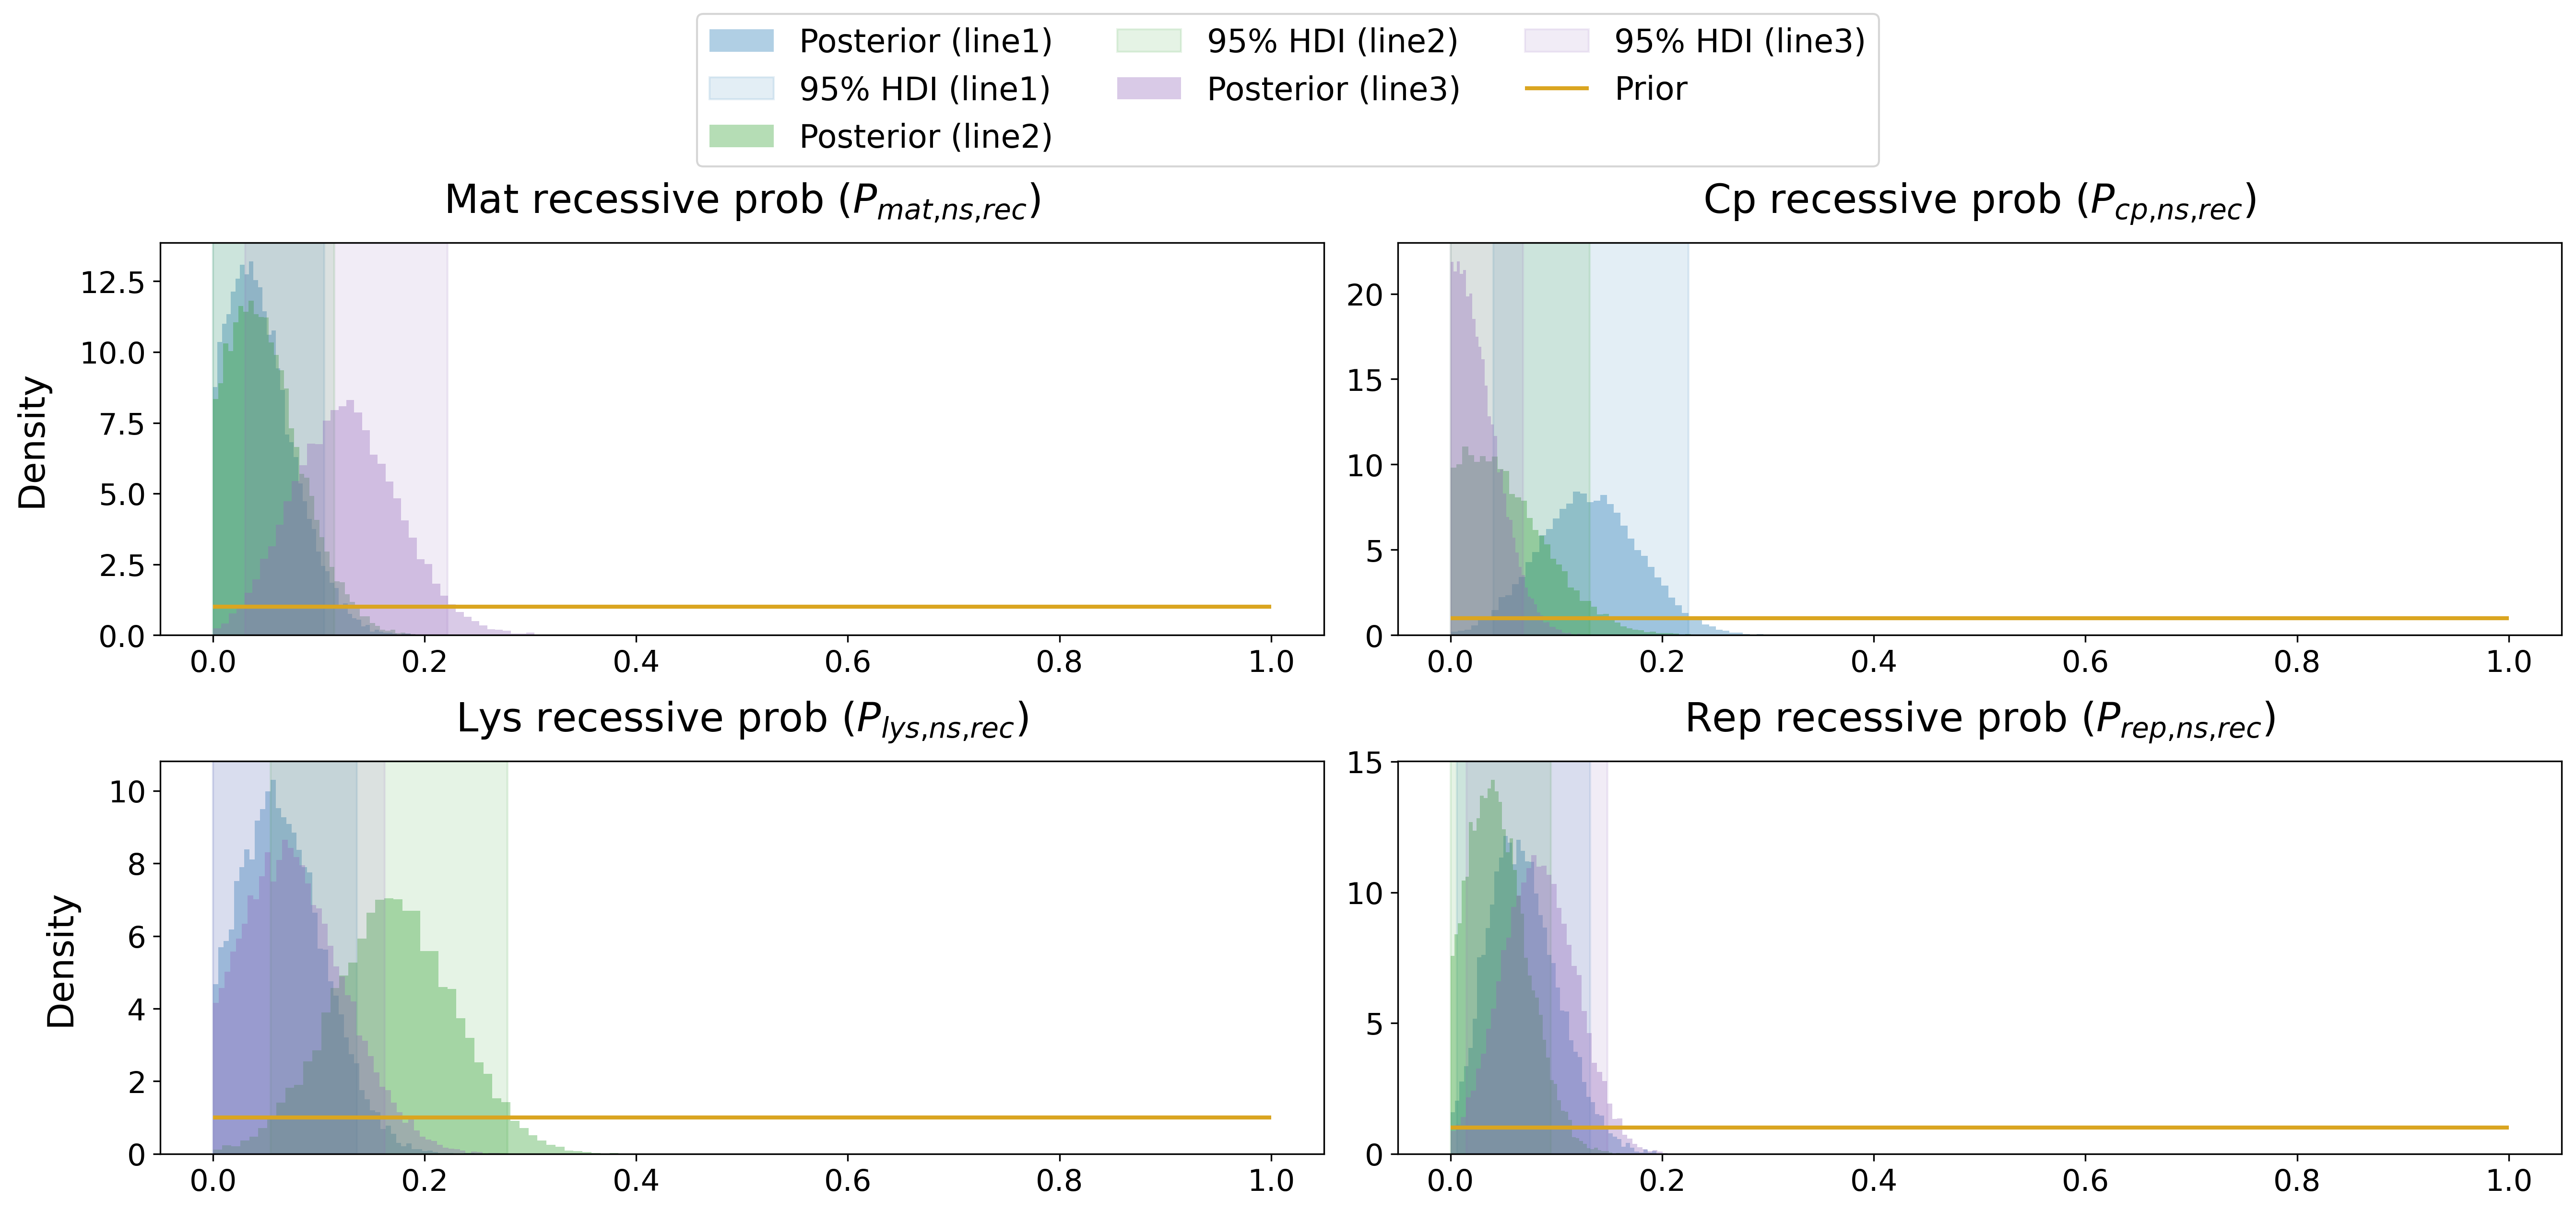

In [12]:
posterior_samples_path_lst = [model_B_control_line1_samples_path,model_B_control_line2_samples_path,model_B_control_line3_samples_path]
stats_path_lst = [model_B_control_line1_stats_path,model_B_control_line2_stats_path,model_B_control_line3_stats_path]
plot_posteriors_overlay_wraper(posterior_samples_path_lst,stats_path_lst,'B',param_2_name,('line1','line2','line3'),params_to_use=['p_mat_nonsyn_rec','p_cp_nonsyn_rec','p_lys_nonsyn_rec','p_rep_nonsyn_rec'],ncols=2) # , colors=["tab:blue", "tab:orange", "tab:green"]

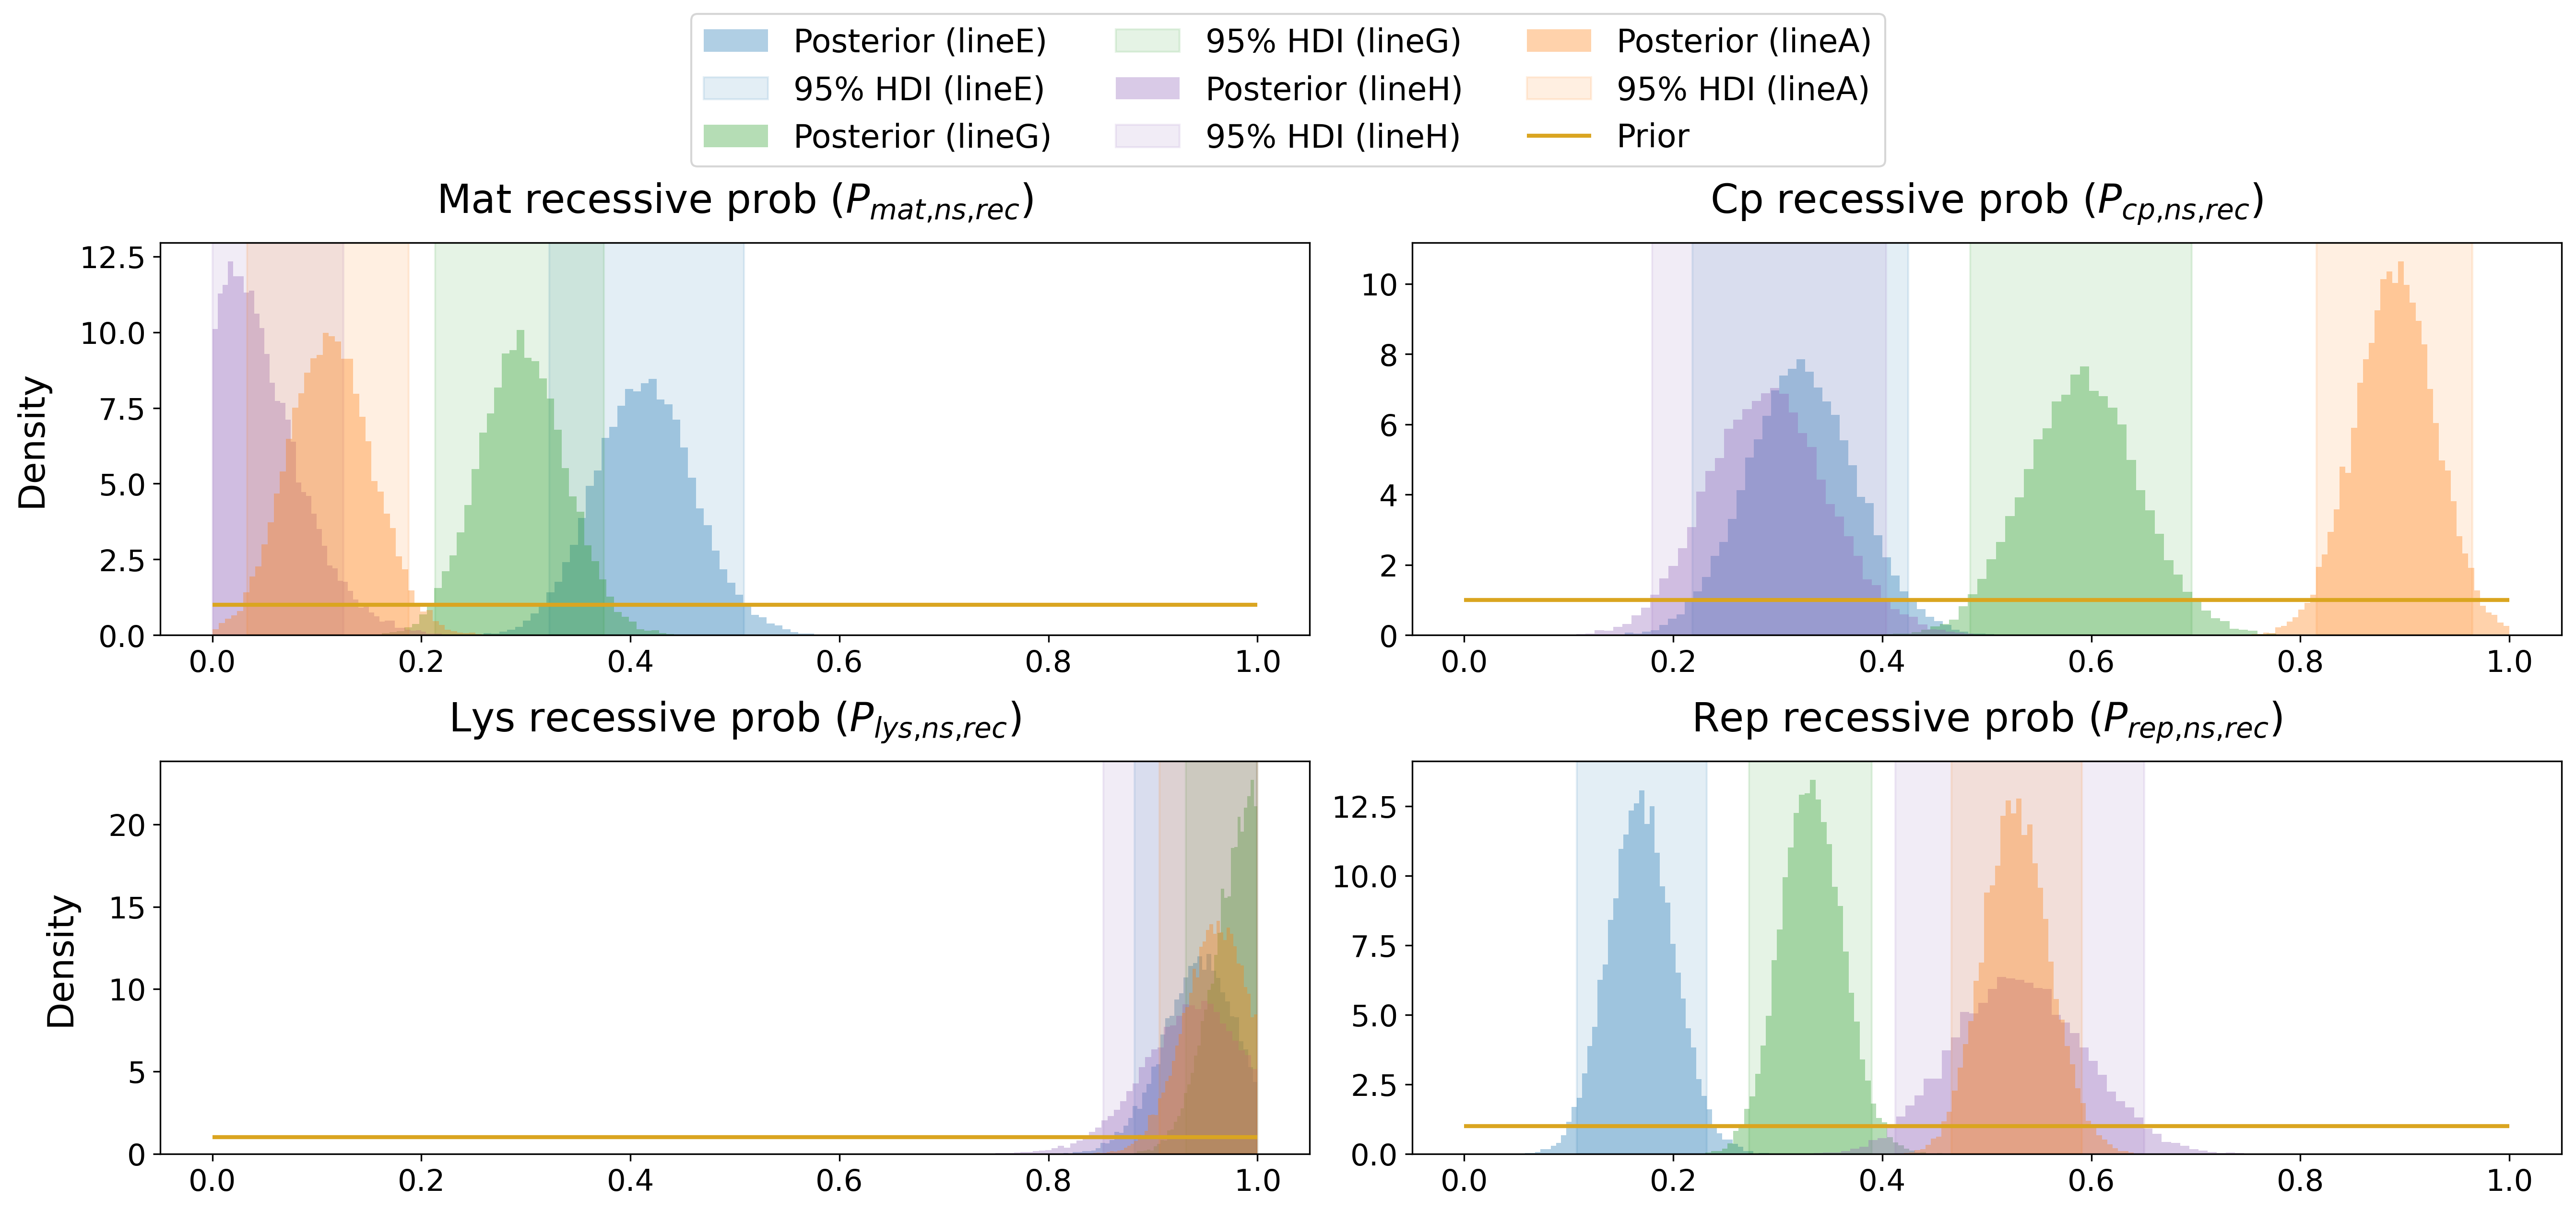

In [16]:
posterior_samples_path_lines_lst = [model_B_posterior1_lineE_samples_path,model_B_posterior1_lineG_samples_path,model_B_posterior1_lineH_samples_path,model_B_posterior1_lineA_samples_path]
stats_path_lines_lst = [model_B_stats1_lineE_path,model_B_stats1_lineG_path,model_B_stats1_lineH_path,model_B_stats1_lineA_path]
plot_posteriors_overlay_wraper(posterior_samples_path_lines_lst,stats_path_lines_lst,'B',param_2_name,('lineE','lineG','lineH','lineA'),params_to_use=['p_mat_nonsyn_rec','p_cp_nonsyn_rec','p_lys_nonsyn_rec','p_rep_nonsyn_rec'],ncols=2) # , colors=["tab:blue", "tab:orange", "tab:green"]  

# NN performance

In [13]:
modelA_test_results_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/nn_performance_test_1/nn_test_2k_sims_2/nn_test_results_2k_sims.csv'
modelB_test_results_path = '/sternadi/home/volume3/yael/model_AB/model_B/nn_performance_test_1/nn_test_2k_sims_2/nn_test_results_2k_sims.csv'

In [22]:
def plot_comparative_diagnostics(df_a, df_b, param_to_name, output_dir, save_fig, 
                                 plot_type='both', label_a='Model A', label_b='Model B'):
    plt.rcParams.update({'mathtext.fontset': 'stix'})
    if save_fig:
        os.makedirs(output_dir, exist_ok=True)

    params_a = set(df_a['parameter'].unique())
    params_b = set(df_b['parameter'].unique())
    all_params_list = sorted(list(params_a | params_b)) 
    n_params = len(all_params_list)

    color_a = 'tab:blue' #"xkcd:sky blue"# 'steelblue'
    color_b = 'tab:green' #'forestgreen' 

    if plot_type == 'both':
        rows, cols = 8, 4 
        figsize = (22, 36)
    else:
        rows, cols = 4, 4 
        figsize = (20, 22)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes_flat = axes.flatten()

    for i, p_name in enumerate(all_params_list):
        display_name = param_to_name.get(p_name, p_name)
        
        if plot_type == 'both':
            ax_parity = axes_flat[2 * i]
            ax_hist = axes_flat[2 * i + 1]
        elif plot_type == 'parity':
            ax_parity = axes_flat[i]
        else: 
            ax_hist = axes_flat[i]

        sub_a = df_a[df_a['parameter'] == p_name] if p_name in params_a else None
        sub_b = df_b[df_b['parameter'] == p_name] if p_name in params_b else None

        # --- Plot 1: Parity Plot (using ax.scatter) ---
        if plot_type in ['both', 'parity']:
            if sub_a is not None:
                ax_parity.scatter(sub_a["true_value"], sub_a["MAP_estimate"], 
                                  color=color_a, alpha=0.5, edgecolors='none', s=20,
                                  label=label_a if i == 0 else None)
            if sub_b is not None:
                ax_parity.scatter(sub_b["true_value"], sub_b["MAP_estimate"], 
                                  color=color_b, alpha=0.5, edgecolors='none', s=20,
                                  label=label_b if i == 0 else None)
            
            # Identity Line
            ax_parity.plot([-2, 2], [-2, 2], 'r--', alpha=0.8)
            ax_parity.set_xlim(-2, 2)
            ax_parity.set_ylim(-2, 2)
            
            ax_parity.set_title(display_name, fontsize=14, fontweight='bold', pad=15)
            ax_parity.set_xlabel("True Value", fontsize=12)
            ax_parity.set_ylabel("MAP Estimate", fontsize=12)
            if i == 0:
                ax_parity.legend(loc='upper left', fontsize=14, frameon=True)

        # --- Plot 2: Histogram Plot (using ax.hist) ---
        if plot_type in ['both', 'hist']:
            # Define bins to ensure both models use the same scale
            curr_xlim = (-1.05, 1.05) if i < 10 else (-0.2, 0.2)
            bins_for_this_plot = np.linspace(curr_xlim[0], curr_xlim[1], 50)

            if sub_a is not None:
                log_ratio_a = np.log10(sub_a["ratio_MAP_true"] + 1e-9)
                ax_hist.hist(log_ratio_a, bins=bins_for_this_plot, color=color_a, alpha=0.3, 
                             histtype='stepfilled', edgecolor='none', density=True,
                             label=label_a if (i == 0 and plot_type == 'hist') else None)
            if sub_b is not None:
                log_ratio_b = np.log10(sub_b["ratio_MAP_true"] + 1e-9)
                ax_hist.hist(log_ratio_b, bins=bins_for_this_plot, color=color_b, alpha=0.4, 
                             histtype='stepfilled', edgecolor='none', density=True,
                             label=label_b if (i == 0 and plot_type == 'hist') else None)
            
            # Formatting
            ax_hist.set_xlim(curr_xlim)

                
            ax_hist.set_title(display_name, fontsize=22, fontweight='medium', pad=15)
            ax_hist.set_xlabel("log10(MAP Error Ratio)", fontsize=18, labelpad=10)
            ax_hist.set_ylabel("Density", fontsize=18, labelpad=10)
            
            if i == 0 and plot_type == 'hist':
                ax_hist.legend(loc='upper right', fontsize=16, frameon=True)

    # --- Separation Lines & Layout ---
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.subplots_adjust(hspace=0.7, wspace=0.3)
    
    for r in range(1, rows):
        ax_above = axes[r-1, 0]
        ax_below = axes[r, 0]
        bbox_above = ax_above.get_position()
        bbox_below = ax_below.get_position()
        y_pos = (bbox_above.y0 + bbox_below.y1) / 2

        line = mlines.Line2D([0.02, 0.98], [y_pos, y_pos], color='black', 
                             linewidth=1.0, linestyle='--', alpha=0.2,
                             transform=fig.transFigure, figure=fig)
        fig.add_artist(line)

    if save_fig:
        save_path = os.path.join(output_dir, f"comparison_16params_{plot_type}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")
    else:
        plt.show()
        
def plot_comparison_wrapper(path_a, path_b, param_2_name, output_dir=None, save_fig=False, plot_type='both'):
    df_a = pd.read_csv(path_a)
    df_b = pd.read_csv(path_b)
    plot_comparative_diagnostics(df_a, df_b, param_2_name, output_dir, save_fig, plot_type=plot_type)

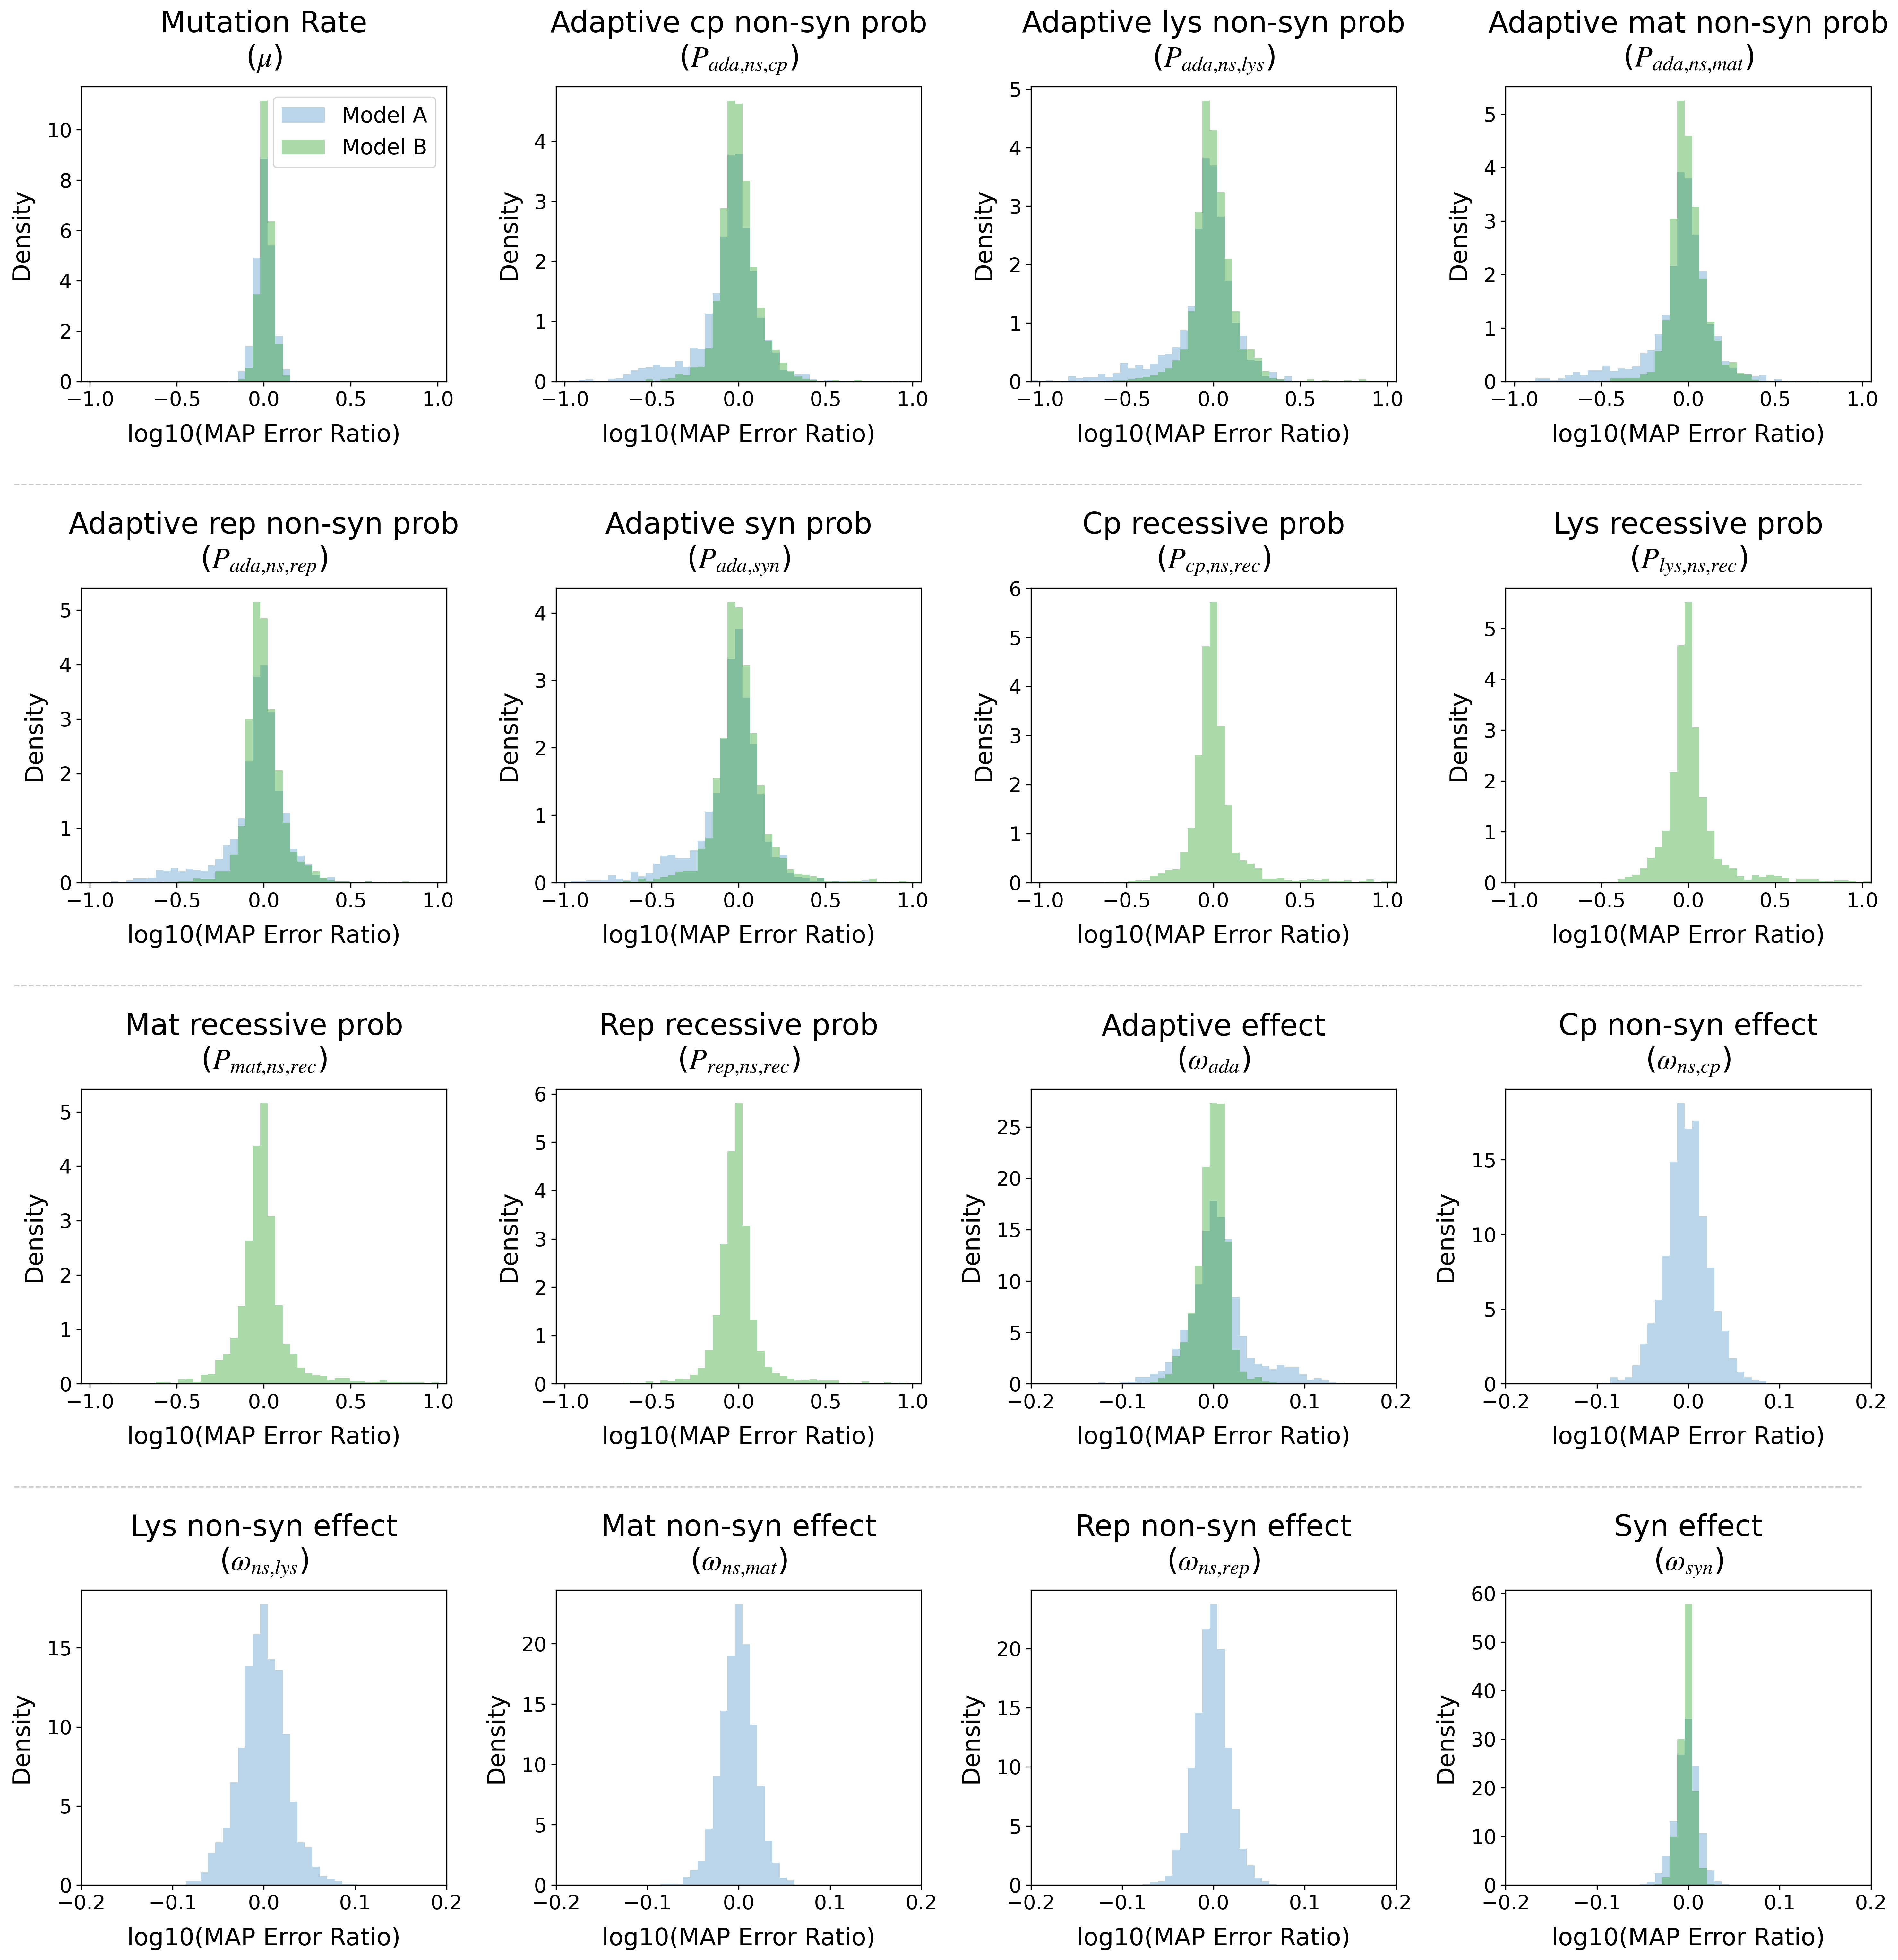

In [23]:
plot_comparison_wrapper(modelA_test_results_path,modelB_test_results_path,param_2_name2,output_dir=None, save_fig=False, plot_type='hist')

## PPC 

In [27]:
def get_emp_sumstats_dict(emp_smst_path):
    with open(emp_smst_path, 'rb') as f:
        emp_sumstat_by_line_dict = pickle.load(f)
    return {key: val for key,val in emp_sumstat_by_line_dict.items() if key!='A'}

def dict_vals_to_lst(probs_dict):
    return list(probs_dict.values())

def simulate_for_checks_AB(num_of_simulations,model, thetas, pop_size, fixed_param_lst,long_sumstat=0):
    print(f'{fixed_param_lst=}')
    syn_probs_by_gene_lst = dict_vals_to_lst(syn_probs_by_gene)
    gene_probs_lst = dict_vals_to_lst(gene_probs)
    simulations = []
    for i in range(num_of_simulations):
        if i%10 ==0:
            print(f'generated {i} simulations')
        simulations.append(simulate_AB(thetas, syn_probs_by_gene_lst,gene_probs_lst,model, 10,10**-5, pop_size,fixed_param_lst,long_sumstat=long_sumstat)) 
    return torch.stack(simulations)

def extract_passages(simulations, passages=[5,8,10]):
    if len(passages) ==  1:
        p = []
        for i in passages:
            p.append(simulations[:, i*10:i*10+10])
        passages_res = torch.cat(p)
    else:
        passages_res = {}
        for i in passages:
            passages_res[i] = torch.tensor(simulations[:, i*10:i*10+10])
    return passages_res

def get_simulations_sumstat_AB(num_of_simulations,model, thetas, pop_size,fixed_param_lst, passages=[10]):
    sims = simulate_for_checks_AB(num_of_simulations,model, thetas, pop_size,fixed_param_lst)
    return extract_passages(sims, passages)

def get_MAP_vals_as_df(MAP_path):
    res_summary = pd.read_csv(MAP_path)
    return res_summary[['param','MAP']]

In [28]:
def plot_sim_vs_empirical_box(
    empirical_summaries,
    sim_summaries: torch.Tensor,
    MOI,
    labels=None,
    ax=None,
    show=True,
    figsize=(16, 5),
):
    """
    Compare simulated vs empirical summary statistics.

    Parameters
    ----------
    empirical_summaries : (10,) or (n_emp, 10) array-like or torch.Tensor
        Empirical summary statistics. Can be a single vector (length 10) or a
        collection of vectors.
    sim_summaries : torch.Tensor, shape (n_sims, 10)
        Simulated summary statistics.
    labels : list[str], length 10
        X-axis labels (summary statistic names).
    ax : matplotlib Axes or None
        If None, creates a new figure+axes.
    show : bool
        Whether to call plt.show().
    figsize : tuple
        Figure size if creating a new figure.

    Returns
    -------
    fig, ax
    """
    if labels is None:
        labels = [
            'Mat nonsyn (non-ada)', 'Mat nonsyn (ada)',
            'CP nonsyn (non-ada)', 'CP nonsyn (ada)',
            'Lys nonsyn (non-ada)', 'Lys nonsyn (ada)',
            'Rep nonsyn (non-ada)', 'Rep nonsyn (ada)',
            'Total syn (non-ada)', 'Total syn (ada)'
        ]

    if not isinstance(sim_summaries, torch.Tensor):
        raise TypeError("sim_summaries must be a torch.Tensor of shape (n_sims, 10).")
    if sim_summaries.ndim != 2 or sim_summaries.shape[1] != 10:
        raise ValueError(f"sim_summaries must have shape (n_sims, 10), got {tuple(sim_summaries.shape)}.")

    # Convert sims -> numpy
    sims = sim_summaries.detach().cpu().numpy()

    # Convert empirical -> numpy with shape (n_emp, 10)
    if isinstance(empirical_summaries, torch.Tensor):
        emp = empirical_summaries.detach().cpu().numpy()
    else:
        emp = np.asarray(empirical_summaries)

    if emp.ndim == 1:
        if emp.shape[0] != 10:
            raise ValueError(f"empirical_summaries must be length 10 if 1D, got {emp.shape[0]}.")
        emp = emp[None, :]  # (1, 10)
    elif emp.ndim == 2:
        if emp.shape[1] != 10:
            raise ValueError(f"empirical_summaries must have shape (n_emp, 10), got {emp.shape}.")
    else:
        raise ValueError("empirical_summaries must be 1D (10,) or 2D (n_emp, 10).")

    if len(labels) != 10:
        raise ValueError(f"labels must be length 10, got {len(labels)}.")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    n_stats = 10
    base = np.arange(1, n_stats + 1)

    # Positions for side-by-side boxes
    offset = 0.18
    pos_sim = base - offset
    pos_emp = base + offset

    # Prepare data lists per stat for matplotlib
    sim_data = [sims[:, i] for i in range(n_stats)]
    emp_data = [emp[:, i] for i in range(n_stats)]

    # Boxplots (patch_artist=True lets us color boxes)
    bp_sim = ax.boxplot(
        sim_data,
        positions=pos_sim,
        widths=0.32,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
    )
    bp_emp = ax.boxplot(
        emp_data,
        positions=pos_emp,
        widths=0.32,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
    )

    # Color them differently
    for b in bp_sim["boxes"]:
        b.set_facecolor("darkblue")
        b.set_alpha(0.6)
    for b in bp_emp["boxes"]:
        b.set_facecolor("gray")
        b.set_alpha(0.6)

    for m in bp_sim["medians"]:
        m.set_color("darkblue")  # C2 C0
        m.set_linewidth(2)
    for m in bp_emp["medians"]:
        m.set_color("gray")
        m.set_linewidth(2)

    if emp.shape[0] == 1:
        ax.scatter(pos_emp, emp[0, :], marker="o", s=30, zorder=3)

    ax.set_xticks(base)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel("Mutation frequency", fontsize=16,labelpad=10)
    #ax.set_title(f"Simulated vs Empirical (MOI{MOI}) summary statistics")
    ax.grid(True, axis="y", alpha=0.25)

    ax.plot([], [], color="darkblue", lw=8, alpha=0.6, label="Simulations")
    ax.plot([], [], color="gray", lw=8, alpha=0.6, label=f"Empirical MOI-{MOI}")
    ax.legend(frameon=True, loc='upper left',fontsize=14)

    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax

In [29]:
def predictive_check_modelAB_pipeline(MAP_vals_path, pop_size, num_of_sims,model, fixed_param_lst,is_emp_mean_sumstat=False, passages=[10], MAP_vals_lst=None,output_path=None):
    if MAP_vals_lst is not None:
        MAP_thetas_lst = MAP_vals_lst
    else:
        MAP_thetas_df = get_MAP_vals_as_df(MAP_vals_path)
        MAP_thetas_lst = MAP_thetas_df['MAP'].to_list()
    MAP_simulations = get_simulations_sumstat_AB(num_of_sims,model, MAP_thetas_lst, pop_size, fixed_param_lst, passages)

    if output_path!=None:
        torch.save(MAP_simulations, output_path)
    return MAP_simulations, MAP_thetas_df 

In [30]:
moi10_sumstat_path = '/sternadi/home/volume3/yael/Data/MOI10/moi10_sumstats_by_line.pkl'
moi01_sumstat_path = '/sternadi/home/volume3/yael/Data/MOI01/moi01_sumstats_by_line.pkl'

moi01_geno10_p3710_sumstat_path = '/sternadi/home/volume3/yael/Data/MOI01/moi01_p3710_geno10_sumstats_by_line.pkl'

MAP01_A_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_A1/MOI0.1_mean_MAP_values.csv'
MAP01_ens_A_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_A1/MOI0.1_mean_ensemble_MAP_values.csv'
MAP10_B_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_1/MOI10_line_E_G_H_20k_samples_mean_EGH_stats.csv'

In [31]:
with open(moi01_geno10_p3710_sumstat_path, 'rb') as file:
    moi01_geno10_p3710_sumstat = pickle.load(file)

In [32]:
modelA_PPC_output_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_A1/modelA_PPC_sims_sumstat.pt'
# modelA_MAP_simulations, modelA_MAP_thetas_df = predictive_check_modelAB_pipeline(MAP01_A_path,2*10**7,100,model='A',fixed_param_lst=[0,0,0,0],output_path=modelA_PPC_output_path)

In [33]:
emp_dict_01 = get_emp_sumstats_dict(moi01_sumstat_path)
modelA_MAP_simulations = torch.load(modelA_PPC_output_path)

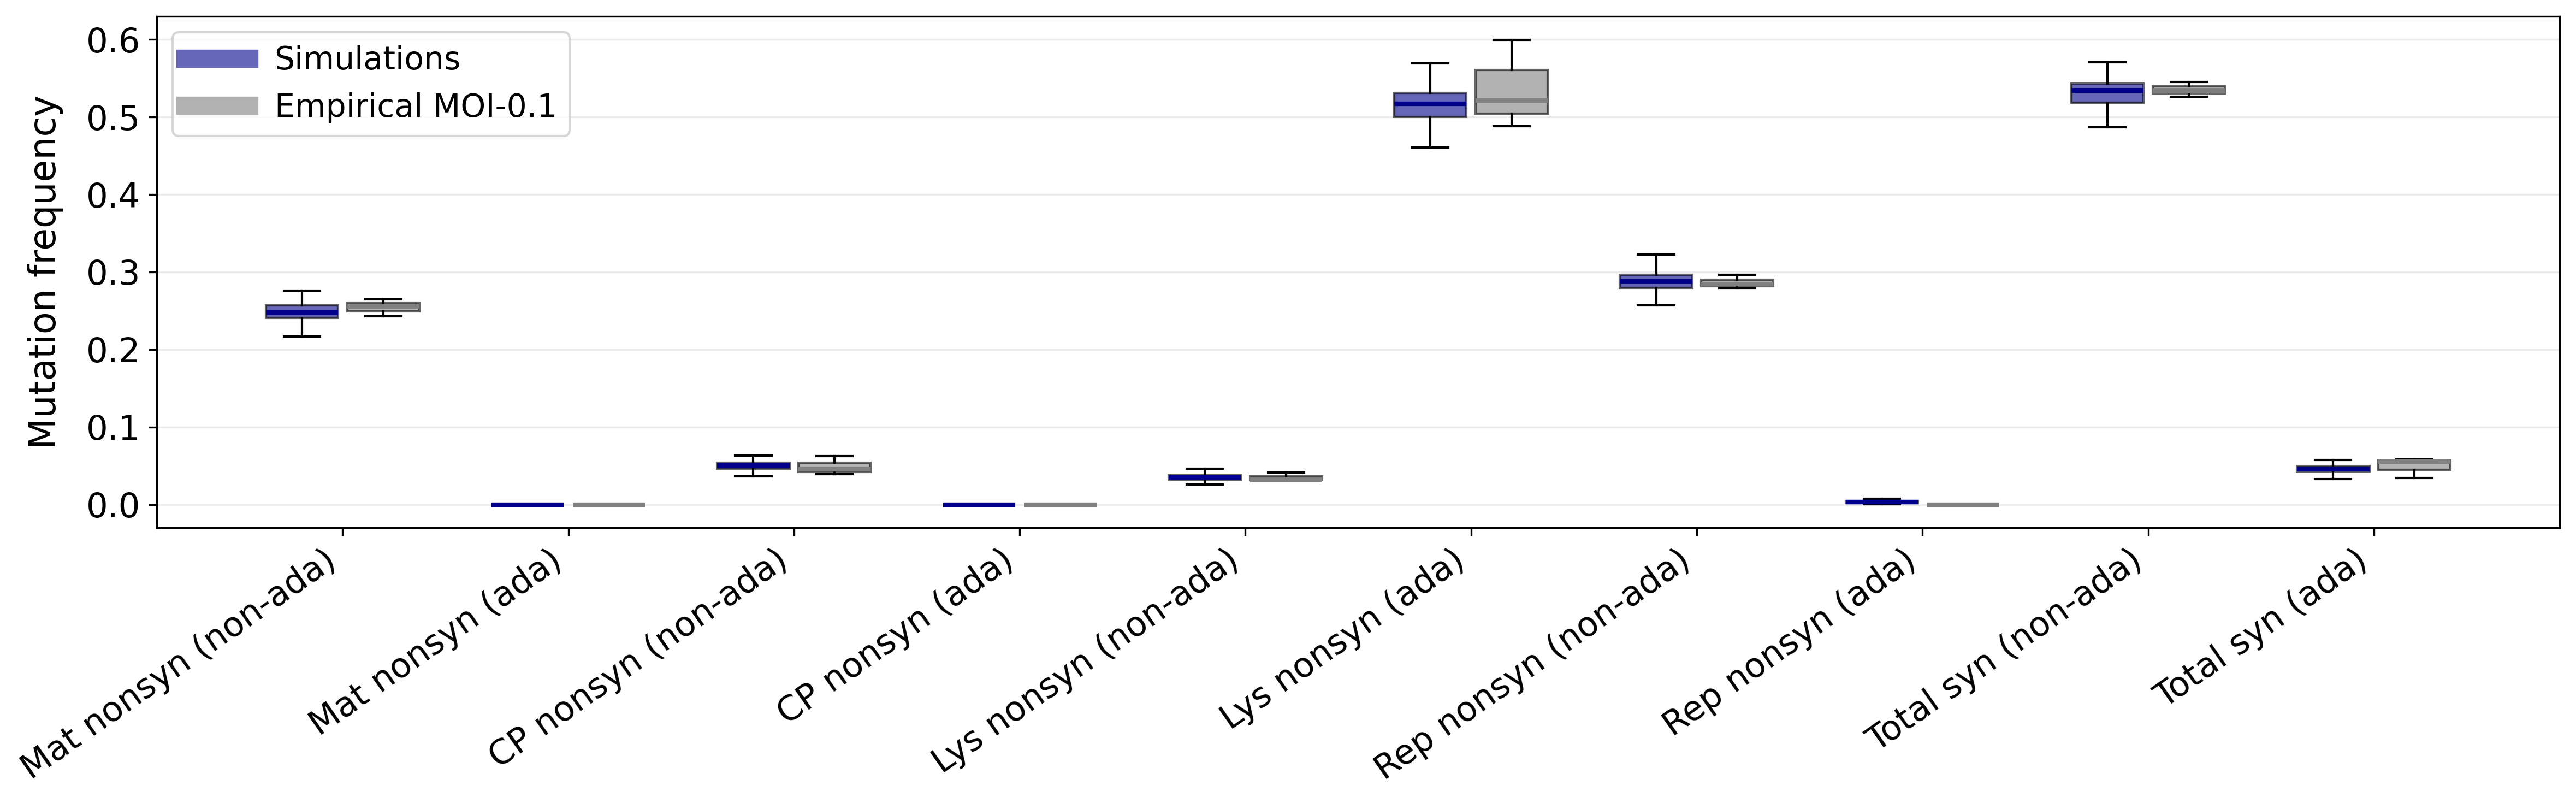

(<Figure size 4800x1500 with 1 Axes>, <Axes: ylabel='Mutation frequency'>)

In [35]:
plot_sim_vs_empirical_box(list(emp_dict_01.values()), modelA_MAP_simulations, 0.1)

In [36]:
modelB_PPC_output_path = '/sternadi/home/volume3/yael/model_AB/model_B/results_1/modelB_PPC_sims_sumstat.pt'
# modelB_MAP_simulations, modelB_MAP_thetas_df = predictive_check_modelAB_pipeline(MAP10_B_path,2*10**7,100,model='B',fixed_param_lst=[0.81266826,0.71197677,0.7248674,0.7676071],output_path=modelB_PPC_output_path)

In [37]:
emp_dict_10 = get_emp_sumstats_dict(moi10_sumstat_path)
modelB_MAP_sims_from_dir = torch.load(modelB_PPC_output_path)

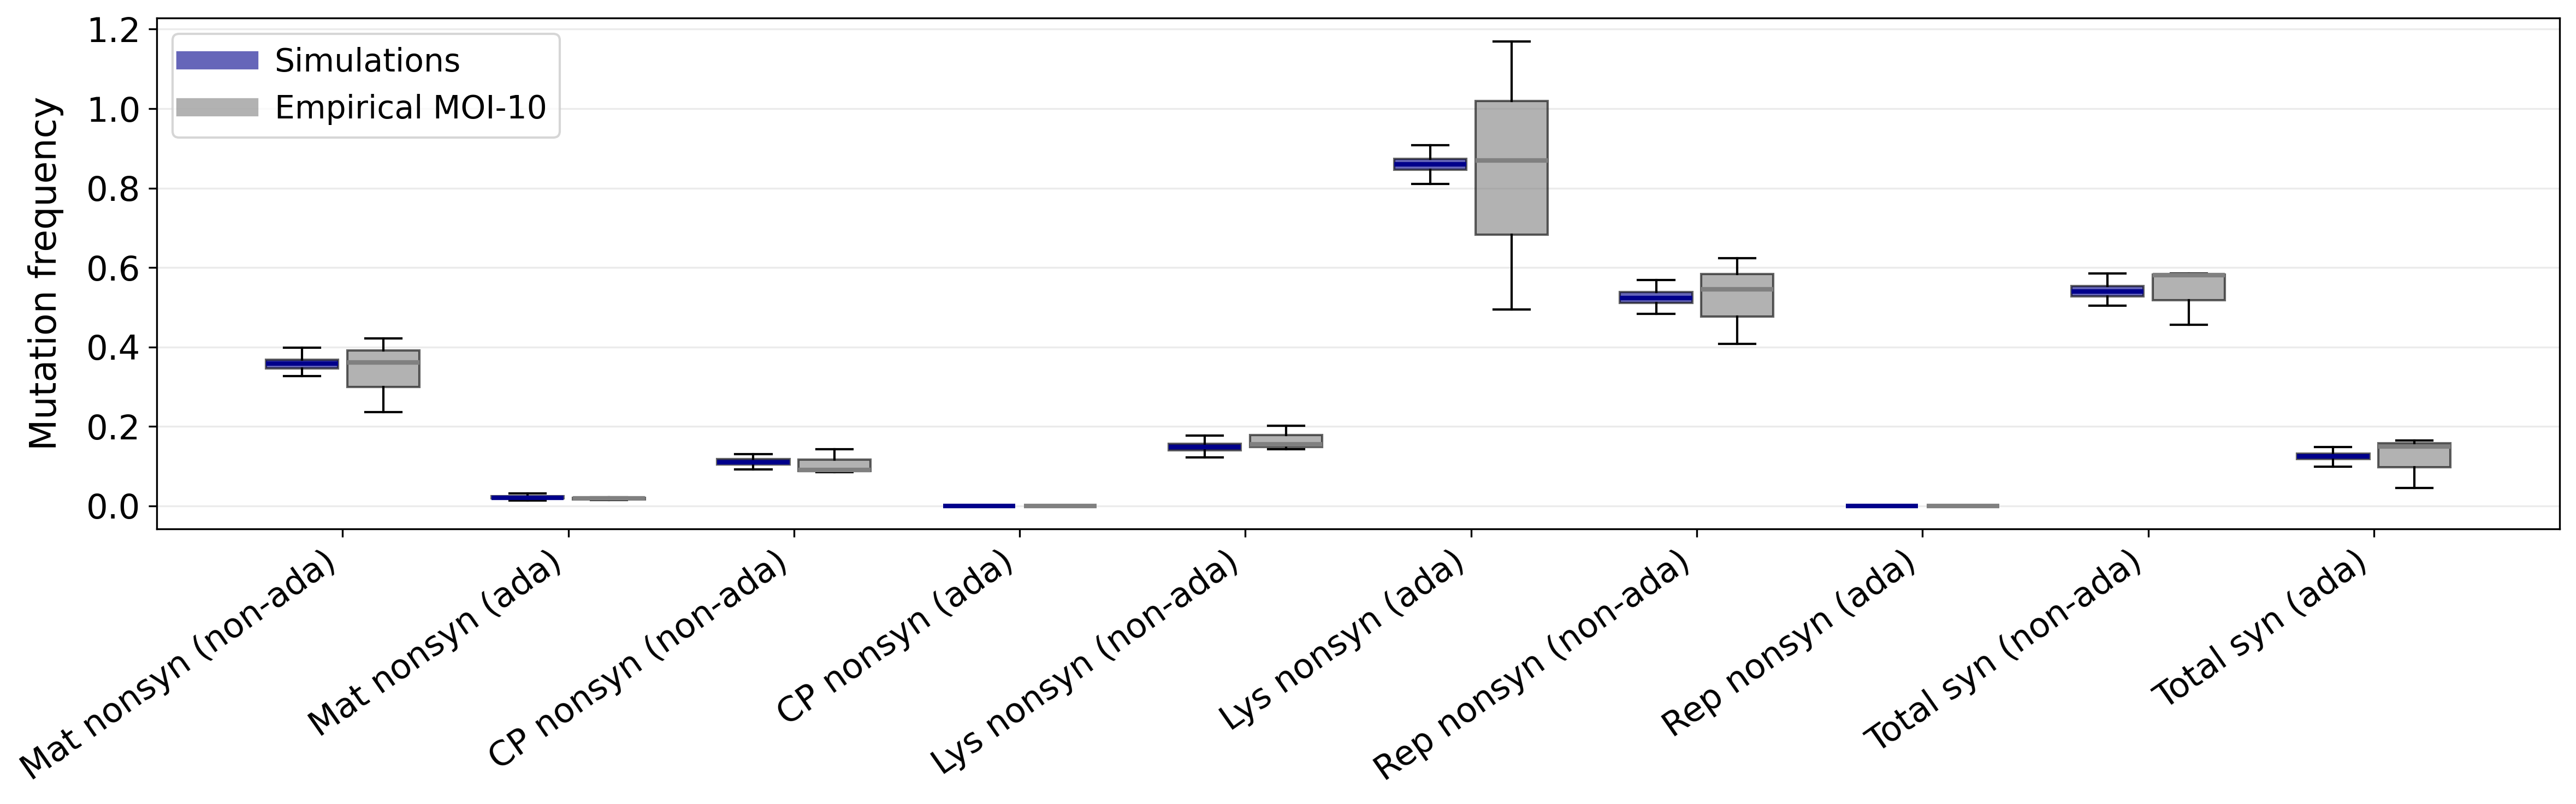

(<Figure size 4800x1500 with 1 Axes>, <Axes: ylabel='Mutation frequency'>)

In [39]:
plot_sim_vs_empirical_box(list(emp_dict_10.values()), modelB_MAP_sims_from_dir,10)

In [30]:
def get_batch_frequency_categories_p(sumstat_tensor, passages=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]):
    """
    Parses a batch of summary statistics with flexible passage indexing.
    
    Input:
        sumstat_tensor: Tensor of shape (num_sims, 3003 * len(passages))
        passages: List of integers representing the passages present in the vector.
        
    Returns:
        A dictionary where each key is a category (wt, adaptive, nonsyn),
        containing a nested dictionary mapping passage numbers to tensors of shape (num_sims,).
    """
    num_sims = sumstat_tensor.shape[0] if len(sumstat_tensor.shape) > 1 else 1
    num_passages = len(passages)
    
    # Reshape to (num_sims, num_passages, 3003)
    data = sumstat_tensor.view(num_sims, num_passages, 3003)

    # 1. Reconstruct genotype index mapping
    def generate_indexing(n_categories, max_total):
        for combo in combinations(range(n_categories + max_total), n_categories):
            res = []
            prev = -1
            for val in combo:
                res.append(val - prev - 1)
                prev = val
            yield tuple(res)

    genotype_index = list(generate_indexing(10, 5))
    
    wt_idx = None
    adaptive_indices = []
    nonsyn_nonada_indices = []

    ada_cols = [1, 3, 5, 7, 9]
    nonsyn_nonada_cols = [0, 2, 4, 6]

    for i, genotype in enumerate(genotype_index):
        if sum(genotype) == 0:
            wt_idx = i
        
        if any(genotype[idx] > 0 for idx in ada_cols):
            adaptive_indices.append(i)
        elif any(genotype[idx] > 0 for idx in nonsyn_nonada_cols):
            nonsyn_nonada_indices.append(i)

    # 3. Aggregate results per passage
    # We create a mapping: result[category][passage_number] = Tensor(num_sims)
    results = {
        "wt": {},
        "adaptive": {},
        "nonsyn_nonadaptive": {}
    }

    for idx, p_num in enumerate(passages):
        # Extract the specific passage slice for all sims
        passage_slice = data[:, idx, :] # Shape: (num_sims, 3003)
        
        results["wt"][p_num] = passage_slice[:, wt_idx]
        results["adaptive"][p_num] = passage_slice[:, adaptive_indices].sum(dim=1)
        results["nonsyn_nonadaptive"][p_num] = passage_slice[:, nonsyn_nonada_indices].sum(dim=1)

    return results

In [11]:
MAP01_thetas_df = get_MAP_vals_as_df(MAP01_A_path)
MAP01_thetas_lst = MAP01_thetas_df['MAP'].to_list()

In [36]:
MAP01_sims_full_geno_all_passages = simulate_for_checks_AB(10,'A', MAP01_thetas_lst, 2*10**7, [0,0,0,0],long_sumstat=1)

fixed_param_lst=[0, 0, 0, 0]
generated 0 simulations
model A priors: model_priors_dict={'mu': 0.25031915, 'w_syn': 0.98482716, 'w_nonsyn_mat': 0.81266826, 'w_nonsyn_cp': 0.71197677, 'w_nonsyn_lys': 0.7248674, 'w_nonsyn_rep': 0.7676071, 'w_ada': 1.671391, 'p_ada_syn': 0.0026082455, 'p_ada_ns_mat': 3.7200896e-06, 'p_ada_ns_cp': 9.67673e-08, 'p_ada_ns_lys': 0.08250337, 'p_ada_ns_rep': 0.00016127333, 'p_mat_nonsyn_rec': 0, 'p_cp_nonsyn_rec': 0, 'p_lys_nonsyn_rec': 0, 'p_rep_nonsyn_rec': 0}

processed params
simulate_sequence_sampling=True, params: [0.25031915, 0.98482716, 0.81266826, 0.71197677, 0.7248674, 0.7676071, 1.671391, 0.0026082455, 3.7200896e-06, 9.67673e-08, 0.08250337, 0.00016127333]
got prot probs p0
Audit: Total probability captured: 0.999991
Audit: Total probability leaked: 0.000009

simulated passage 0
Audit: Total probability captured: 0.999986
Audit: Total probability leaked: 0.000014

got mutations

created passage 1!

created passage 2!

created passage 3!

created passa

Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
wrangel data func - memory usage of one simulation: 58144

 wrangled data 


 got long for all passages: 
len(data)=30030
model A priors: model_priors_dict={'mu': 0.25031915, 'w_syn': 0.98482716, 'w_nonsyn_mat': 0.81266826, 'w_nonsyn_cp': 0.71197677, 'w_nonsyn_lys': 0.7248674, 'w_nonsyn_rep': 0.7676071, 'w_ada': 1.671391, 'p_ada_syn': 0.0026082455, 'p_ada_ns_mat': 3.7200896e-06, 'p_ada_ns_cp': 9.67673e-08, 'p_ada_ns_lys': 0.08250337, 'p_ada_ns_rep': 0.00016127333, 'p_mat_nonsyn_r


created passage 5!

created passage 6!

created passage 7!

created passage 8!

created passage 9!

created passage 10!

reached simulate sequencing!!

simulating sequence sampling:
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935
Audit: Total probability leaked: 0.000065
Audit: Total probability captured: 0.999935

In [39]:
genotype_summary_ppc_allp = get_batch_frequency_categories_p(MAP01_sims_full_geno_all_passages)

In [34]:
genotype_summary_emp01_p3710_line1 = get_batch_frequency_categories_p(moi01_geno10_p3710_sumstat[1],[3,7,10])
genotype_summary_emp01_p3710_line2 = get_batch_frequency_categories_p(moi01_geno10_p3710_sumstat[2],[3,7,10])
genotype_summary_emp01_p3710_line3 = get_batch_frequency_categories_p(moi01_geno10_p3710_sumstat[3],[3,7,10])

In [127]:
def plot_empirical_vs_simulations(empirical_list, sim_data):
    plt.figure(figsize=(14, 8))
    
    colors = {
        'wt': 'steelblue',       
        'adaptive': 'purple', 
        'nonsyn_nonadaptive': 'darkorange' 
    }
    
    names = {
        'wt': 'Wild Type',
        'adaptive': 'Adaptive',
        'nonsyn_nonadaptive': 'Non-adaptive Nonsyn'
    }

    emp_markers = ['o', 's', '^'] 
    
    for cat, color in colors.items():
        passages = sorted(sim_data[cat].keys())
        data_matrix = torch.stack([sim_data[cat][p] for p in passages]).numpy().T
        
        for i in range(data_matrix.shape[0]):
            plt.plot(passages, data_matrix[i, :], color=color, linestyle='-', 
                     alpha=0.25, linewidth=1, zorder=1)

    for line_idx, emp_line in enumerate(empirical_list):
        marker = emp_markers[line_idx % len(emp_markers)]
        
        for cat, color in colors.items():
            emp_passages = sorted(emp_line[cat].keys())
            emp_values = [emp_line[cat][p].item() for p in emp_passages]
            
            plt.plot(emp_passages, emp_values, color=color, linestyle='-.', 
                     marker=marker, linewidth=2, markersize=8, 
                     zorder=5, markeredgecolor='black', markeredgewidth=0.5)

    legend_handles = []

    legend_handles.append(mlines.Line2D([], [], color='none', label='Genotype type:'))
    for cat, color in colors.items():
        legend_handles.append(mlines.Line2D([], [], color=color, lw=2, label=names[cat]))

    legend_handles.append(mlines.Line2D([], [], color='none', label='')) # Spacer

    legend_handles.append(mlines.Line2D([], [], color='none', label='Source:'))
    legend_handles.append(mlines.Line2D([], [], color='gray', linestyle='-', lw=2, label='Empirical'))
    legend_handles.append(mlines.Line2D([], [], color='gray', linestyle='--', lw=2, label='Simulations'))

    legend_handles.append(mlines.Line2D([], [], color='none', label='')) # Spacer

    legend_handles.append(mlines.Line2D([], [], color='none', label='Line:'))
    for i in range(len(empirical_list)):
        legend_handles.append(mlines.Line2D([], [], color='gray', marker=emp_markers[i], 
                                            linestyle='none', markersize=8, label=f'Line {i+1}'))

    plt.xlabel("Passage", fontsize=16, labelpad=10)
    plt.ylabel("Frequency", fontsize=16, labelpad=10)
    plt.xticks(range(1, 11))
    plt.ylim(-0.02, 0.8)
    plt.xlim(0.8, 10.2)
    plt.grid(True, linestyle=':', alpha=0.5)

    plt.legend(handles=legend_handles, bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True,fontsize=12)
    
    plt.tight_layout()
    plt.show()

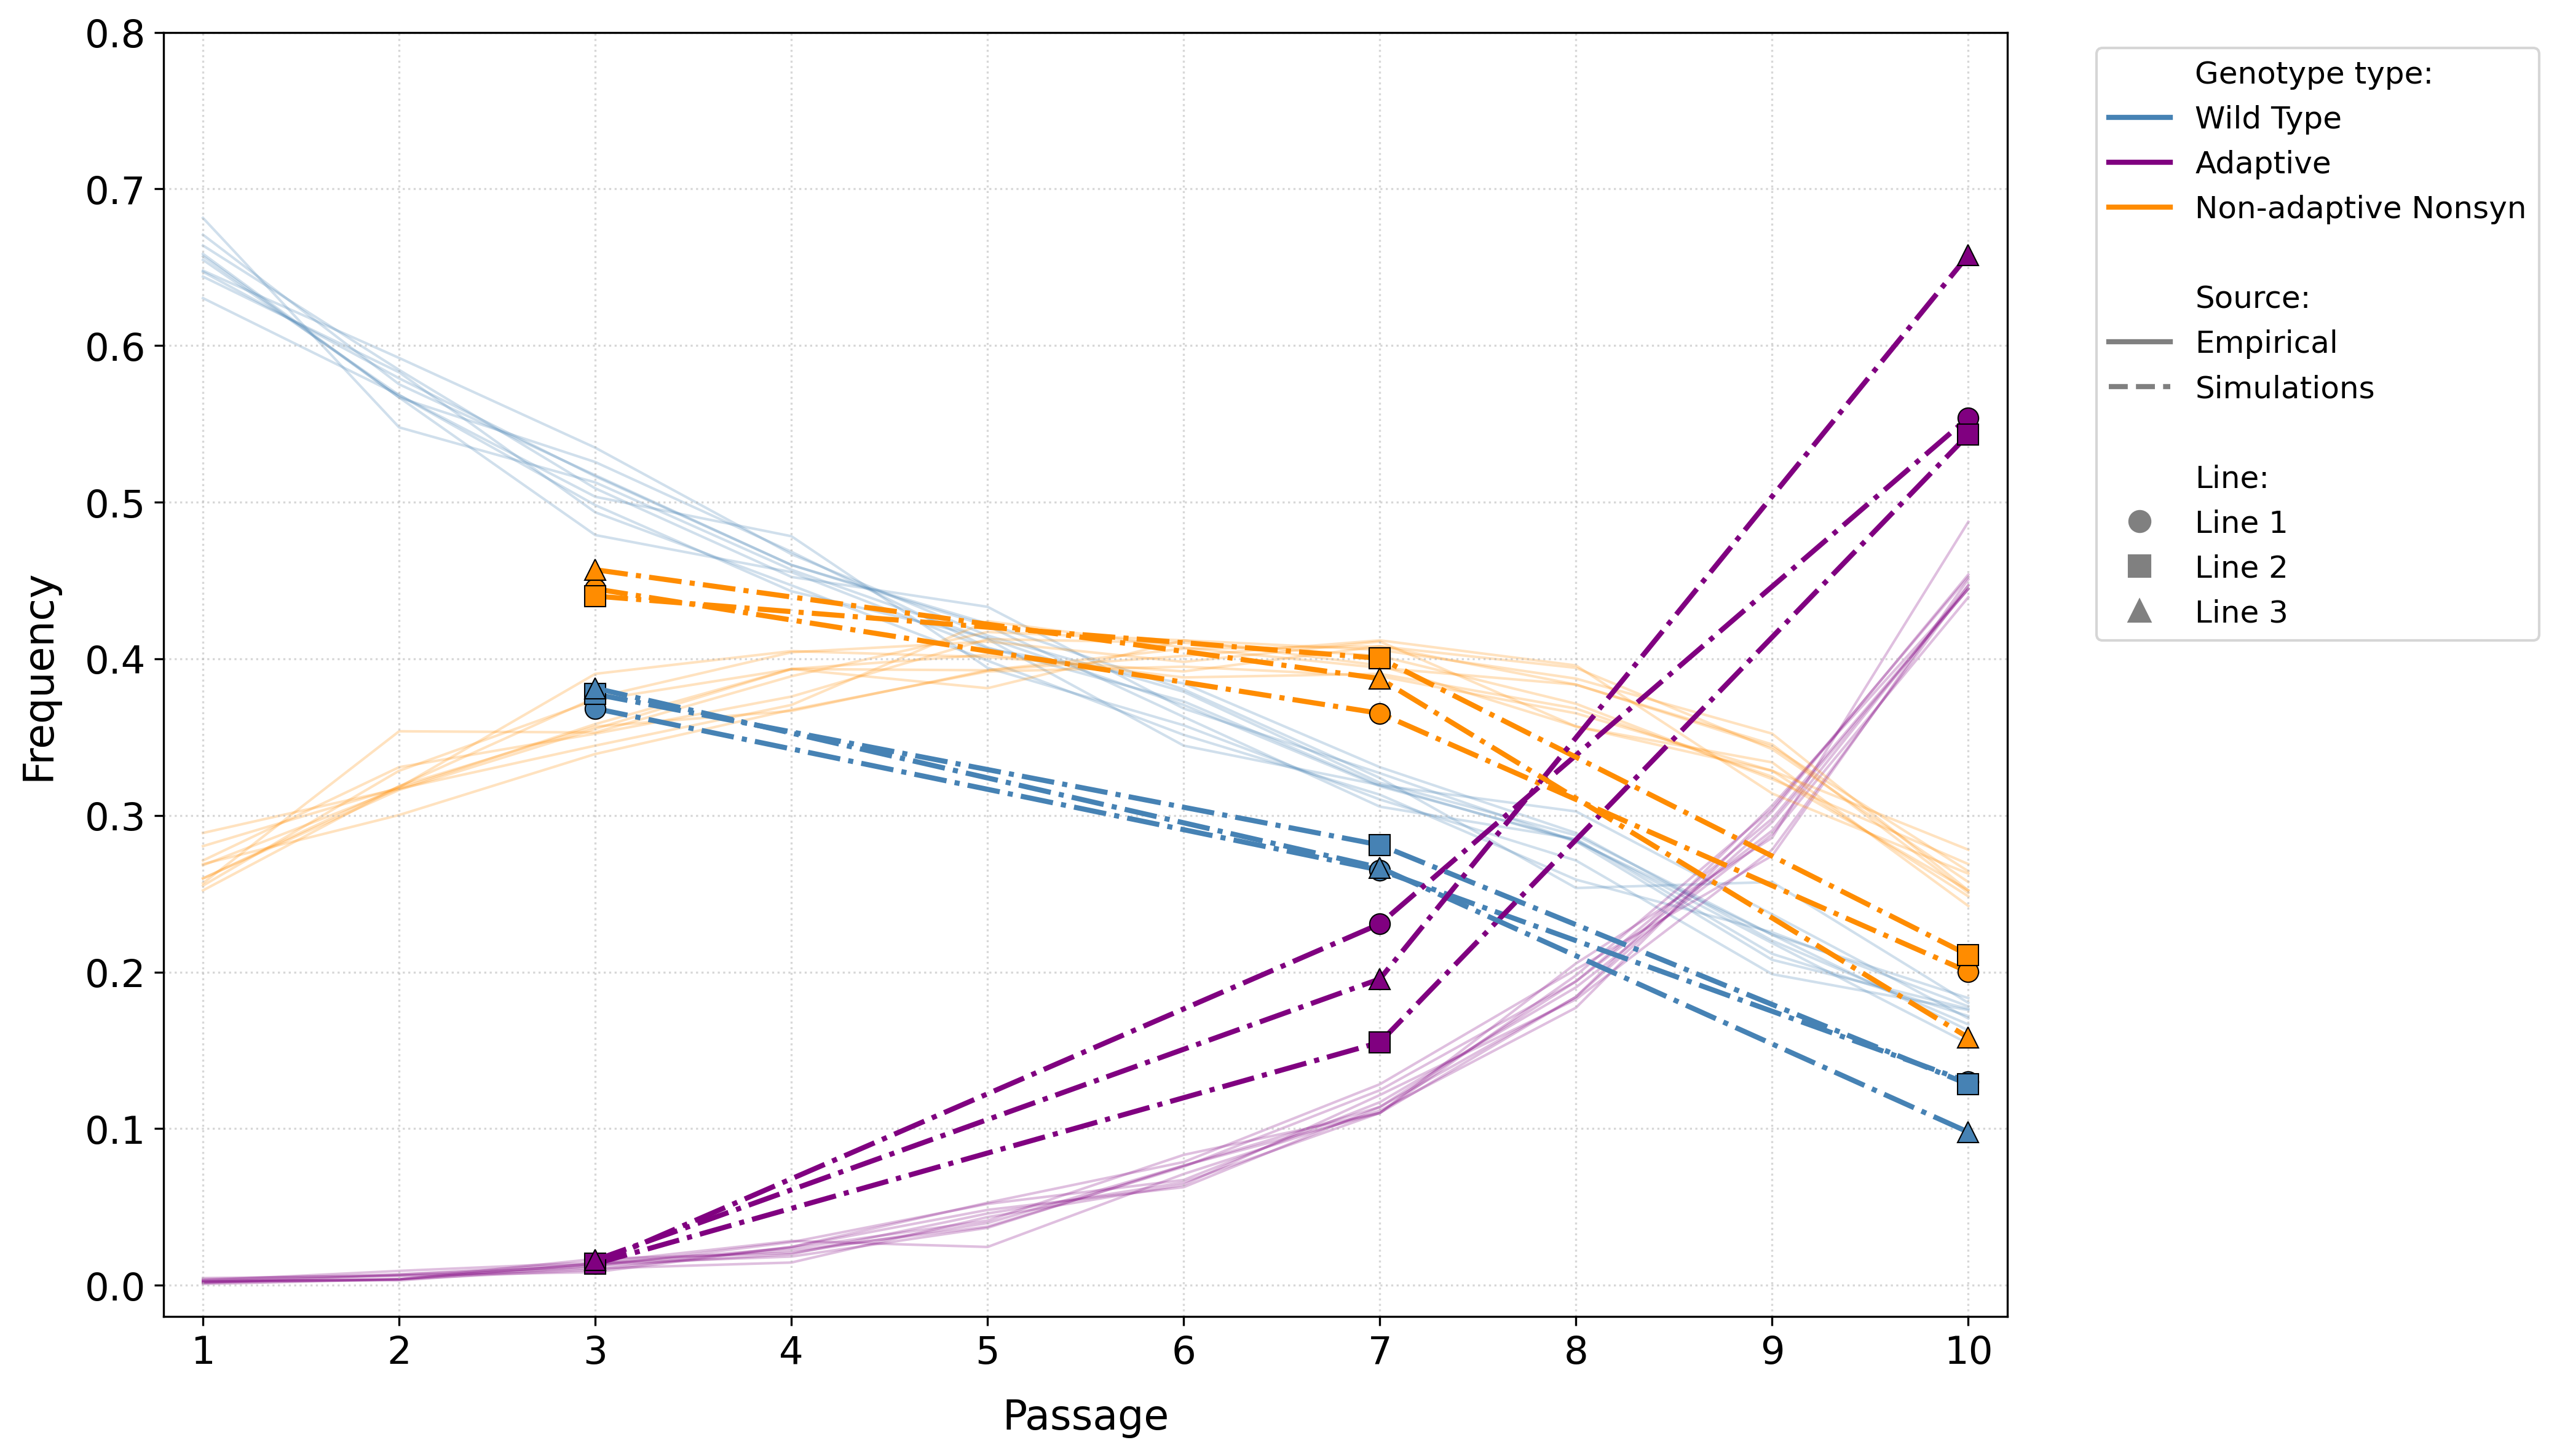

In [128]:
plot_empirical_vs_simulations([genotype_summary_emp01_p3710_line1,genotype_summary_emp01_p3710_line2,genotype_summary_emp01_p3710_line3],genotype_summary_ppc_allp)